# CONSTRUCCIÓN DATASET

## Fuente datos
“El dataset base proviene de Make Music Equal (licencia CC BY-SA 4.0).
Este fue enriquecido con datos obtenidos mediante la API de Chartmetric, los cuales poseen restricciones de uso. Por este motivo, las variables derivadas de dicha fuente fueron transformadas y agregadas de forma tal que no permiten reconstruir los valores originales.”

PASO 1: Base de artistas para obtener IDs antes de conectar a la API.
Fuente: Make Music Equal (CC BY-SA 4.0)
La base de datos de artistas se descargó del dataset de acceso público MakeMusicEqual versión 3/3/2026: 936420, 10.
https://chartmetric-public.s3.us-west-2.amazonaws.com/make-music-equal/mme_artist_info.csv 
Se eliminaron registros duplicados [nombre + url de artista]: 172
Resultado: 936248 filas/artistas. 
Legal: This work is licensed under a Creative Commons Attribution-ShareAlike 4.0 International License.


PASO 2: Construcción de las cohortes de datos a extraer
Base de datos MakeMusicEqual ordenada por Chartmetric_rank (rank 1 a 936248)
-cohorte 1: 1400 registros 
-cohorte 2: 5600 registros 

Notas:
Hay discontinuidades en el atributo Chartmetric_rank (faltan números en la secuencia) porque la base makemusicequal está actualizada al 3/3/26 aunque fueron descargados el 23/3/2026. Misma fecha de acceso a la API. Como la variable chartmetrick_rank es dinámica, esa diferencia de 20 días hace que un artista pueda tener rank = 5 el 3/3/2026 y rank = 9 el 23/3/26. Sin embargo, eso no invalida la selección del conjunto de artistas sobre la cual se construye la extracción de datos porque el objetivo fue definir un conjunto de artistas ordenados por popularidad (medida por una fuenta de datos confiable). Además la variable rank no será utilizada en el análisis. Y por último, se comprueba que el rank puede variar sutilmente pero el conjunto de artistas definidos es predominantemente coincidente. 

PASO 3: API. Extracción de datos
Free Trial. Límite 14 días, 1000 request x día.
Se apunta a dos endpoints: artist metadata y artist live events
La extracción de datos se fragmenta por cohortes y se resguardan archivos parciales.

PASO 4:
Detectada falta de información en live events > 30%. Se busca mejorar la detección de artistas inactivos, muertos o disueltos dentro del conjunto NA.
Estrategias implementadas: 
1-Musicbrainz (para detectar artistas muertos o bandas desarmadas, has_live_data == False)
2-Wikidata (para detectar artistas muertos o bandas desarmadas, has_live_data == False)
3-Jambase API (acceso a eventos 2022-2023 denegado exclusivo de pago)
4-Chartmetric (acceso a eventos 2022-2023: no existe en la base de datos confirmado por staff)
“Data availability constraints limited historical event retrieval to years 2024-2025”
5-Chartmetric: acceso a shows 2026. Si tienen shows en 2026 no están muertos ni disueltos.

PASO 5: INCREMENTO CANTIDAD FEATURES 
Se recuperó más info del jason:
Band
num_sp_editorial_playlists",
"num_sp_playlists",
"sp_editorial_playlist_total_reach",
"num_am_editorial_playlists",
"num_am_playlists",
"num_de_editorial_playlists",
"num_de_playlists",
"de_playlist_total_reach",
"de_editorial_playlist_total_reach",
"num_az_editorial_playlists",
"num_az_playlists",
"num_yt_editorial_playlists",
"num_yt_playlists",
"yt_playlist_total_reach",
"tiktok_top_video_views",
"tiktok_top_video_comments",
"tiktok_track_posts"


## Justificación recorte 

El conjunto de datos inicial se obtuvo del proyecto Make Music Equal (MME) y contiene aproximadamente 936.000 artistas a nivel mundial. La distribución de los artistas según su etapa de carrera (career stage) presenta una fuerte asimetría: más del 80% se clasifica como undiscovered, mientras que las categorías mid-level, mainstream y superstar representan solo una pequeña fracción de la población total.

Dado que el objetivo de esta investigación es analizar la relación entre las métricas de audiencia digital (plataformas de streaming y redes sociales) y la actividad en presentaciones en vivo, el análisis se concentra en artistas con un nivel de actividad en la industria que pueda medirse de manera consistente.

Para obtener un subconjunto manejable y analíticamente significativo, los artistas fueron ordenados utilizando el Chartmetric Artist Rank, y el dataset se restringió a los 7.000 artistas mejor posicionados.

Este umbral permite capturar el segmento de artistas con presencia relevante de audiencia y actividad en vivo observable, al tiempo que excluye la larga cola de artistas con escasa o nula información pública disponible.

Luego de esta selección, la distribución de las etapas de carrera se desplaza hacia las categorías mid-level, mainstream y superstar, que constituyen la población más pertinente para abordar la pregunta de investigación.

# AYUDA MEMORIA

In [376]:
# df1["composition"].unique()
# df["career_stage"].value_counts()

# nulos_cantidad = df['record_label'].isna().sum()
# print(f"La cantidad de nulos es: {nulos_cantidad}")

# porcentaje_nulos = df['record_label'].isna().mean() * 100
# print(f"Porcentaje de nulos: {porcentaje_nulos}%")


# df = df.rename(columns={
#     "artist_name_meta": "artist_name",
#     "code2": "country"
# })


In [377]:
# !pip install pandas numpy matplotlib seaborn scikit-learn jupyter


In [378]:
import pandas as pd
import numpy as np


# DICCIONARIO CATEGORIAS 
en construcción
https://docs.google.com/spreadsheets/d/1GYMC5KjxPj12DdzX9zXU8gm1wND69uT4/edit?usp=sharing&ouid=103822619113308092313&rtpof=true&sd=true

# levanto dataset

In [379]:
df1 = pd.read_csv("cohorte1_raw_1400.csv") #1400 registros con mas columnas 9-4

# df2 = pd.read_csv("cohorte2_raw_1500.csv") #1500 registros hasta 28-3-26
#df2 = pd.read_csv("cohorte2_raw_3003.csv") #3003 registros hasta 31-3-26
#df2 = pd.read_csv("cohorte2_raw_4482.csv") #4482 registros hasta 3/4/26
df2 = pd.read_csv("cohorte2_raw_5600.csv") # 5600 registros hasta 9-4-26 con más columnas

In [380]:
# ==================================================
# 2) CHEQUEO DE DIMENSIONES
# ==================================================
print("df1 shape:", df1.shape)
print("df2 shape:", df2.shape)

# ==================================================
# 3) CHEQUEO DE COLUMNAS
# ==================================================
cols1 = list(df1.columns)
cols2 = list(df2.columns)

print("Cantidad columnas df:", len(cols1))
print("Cantidad columnas df2:", len(cols2))

solo_en_df1 = sorted(set(cols1) - set(cols2))
solo_en_df2 = sorted(set(cols2) - set(cols1))

print("Columnas solo en df1:", solo_en_df1)
print("Columnas solo en df2:", solo_en_df2)

# ==================================================
# 4) SI LAS COLUMNAS SON LAS MISMAS, ALINEAR ORDEN
# ==================================================
if set(cols1) == set(cols2):
    df2 = df2[df1.columns]
    print("Las columnas coinciden. df2 fue reordenado según df1.")
else:
    raise ValueError("Las columnas no coinciden exactamente entre df1 y df2.")

# ==================================================
# 5) CONCATENAR
# ==================================================
df = pd.concat([df1, df2], ignore_index=True)

print("df concatenado:", df.shape)

# ==================================================
# 6) CONTROLES DE DUPLICADOS
# ==================================================
print("Filas duplicadas exactas:", df.duplicated().sum())

if "chartmetric_id" in df.columns:
    print("Duplicados por chartmetric_id:", df["chartmetric_id"].duplicated().sum())
    
    dup_ids = df.loc[df["chartmetric_id"].duplicated(keep=False), "chartmetric_id"] \
                .sort_values() \
                .unique() \
                .tolist()
    
    print("Cantidad de chartmetric_id duplicados:", len(dup_ids))
    
    if len(dup_ids) > 0:
        print("Primeros ids duplicados:", dup_ids[:20])

# ==================================================
# 7) VISTA RÁPIDA DE NULOS
# ==================================================
print(df.isna().sum().sort_values(ascending=False).head(20))

df1 shape: (1400, 77)
df2 shape: (5600, 77)
Cantidad columnas df: 77
Cantidad columnas df2: 77
Columnas solo en df1: []
Columnas solo en df2: []
Las columnas coinciden. df2 fue reordenado según df1.
df concatenado: (7000, 77)
Filas duplicadas exactas: 0
Duplicados por chartmetric_id: 0
Cantidad de chartmetric_id duplicados: 0
avg_low_price_2024          5002
avg_high_price_2024         5002
main_currency_2024          4733
avg_low_price_2025          4579
avg_high_price_2025         4579
gender_title                4561
main_currency_2025          4375
avg_venue_capacity_2024     4005
total_capacity_2024         4005
shows_per_country_2024      3816
total_capacity_2025         3526
avg_venue_capacity_2025     3526
shows_per_country_2025      3375
avg_venue_capacity_total    3130
total_capacity_total        3130
shows_per_country_total     2975
n_countries_total           2947
n_currencies_2024           2947
n_countries_2024            2947
n_cities_2024               2947
dtype: int64

# concatenamos

In [381]:
df = pd.concat([df1, df2], ignore_index=True)


In [382]:
df.shape

(7000, 77)

# SAVE RAW concatenado

In [383]:
# df.to_csv("dataset_raw_concat_1900.csv", index=False)
#df.to_csv("dataset_raw_concat_4403.csv", index=False)
#df.to_csv("dataset_raw_concat_5882.csv", index=False)

df.to_csv("dataset_raw_concat_7000.csv", index=False)



In [384]:
df.columns

Index(['chartmetric_id', 'artist_name', 'country', 'pronoun_title',
       'gender_title', 'record_label', 'hometown_city', 'cm_artist_rank',
       'cm_artist_score', 'career_stage', 'career_stage_score', 'career_trend',
       'career_trend_score', 'primary_genre', 'sp_followers',
       'sp_monthly_listeners', 'sp_popularity', 'sp_playlist_total_reach',
       'ins_followers', 'twitter_followers', 'tiktok_followers',
       'tiktok_likes', 'ycs_subscribers', 'ycs_views',
       'youtube_daily_video_views', 'youtube_monthly_video_views',
       'deezer_fans', 'shazam_count', 'pandora_lifetime_streams',
       'pandora_lifetime_stations_added', 'band', 'num_sp_editorial_playlists',
       'num_sp_playlists', 'sp_editorial_playlist_total_reach',
       'num_am_editorial_playlists', 'num_am_playlists',
       'num_de_editorial_playlists', 'num_de_playlists',
       'de_playlist_total_reach', 'de_editorial_playlist_total_reach',
       'num_az_editorial_playlists', 'num_az_playlists',
  

In [385]:
df.head()

,chartmetric_id,artist_name,country,pronoun_title,gender_title,record_label,hometown_city,cm_artist_rank,cm_artist_score,career_stage,...,main_currency_2025,shows_per_country_2025,shows_per_country_2024,n_shows_total,n_shows_with_capacity_total,total_capacity_total,avg_venue_capacity_total,n_cities_total,n_countries_total,shows_per_country_total
0,214945,Bad Bunny,PR,he/him,male,Rimas Entertainment,Vega Baja,4,98.976377,superstar,...,USD,9.0,NaN,45.0,44.0,1269124.0,28843.727273,5.0,5.0,9.000000
1,2762,Taylor Swift,US,she/her,female,UMG,Reading,1,99.387117,superstar,...,NaN,NaN,4.9,49.0,49.0,3185238.0,65004.857143,15.0,10.0,4.900000
2,3501,Bruno Mars,US,he/him,male,WMG,Los Angeles,2,99.207939,superstar,...,USD,16.0,6.5,55.0,51.0,1370187.0,26866.411765,11.0,6.0,9.166667
3,3479,Justin Bieber,CA,he/him,male,UMG,Stratford,3,99.079736,superstar,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,3852,The Weeknd,CA,he/him,male,UMG,Toronto,7,98.740889,superstar,...,USD,22.0,2.5,49.0,47.0,3080179.0,65535.723404,27.0,4.0,12.250000


# duplicados

In [386]:
# --- 1. CONFIGURACIÓN Y KEY ÚNICA SEGURA ---
# Usamos el ID porque el ID NUNCA es NaN y es la verdad absoluta de Chartmetric
df['unique_entity_key'] = df['chartmetric_id'].astype(str)

# --- 2. ANÁLISIS DE COLISIONES (Nombres iguales, diferentes URL, no son dupli) ---
# Agrupamos por nombre y contamos cuántas URLs distintas existen para ese nombre
analisis = df.groupby('artist_name')['chartmetric_id'].nunique()
colisiones_identidad = analisis[analisis > 1]

# --- 3. IDENTIFICACIÓN DE DUPLICADOS TÉCNICOS ---
# Casos donde la combinación Nombre + URL se repite (deberían ser el mismo registro)
mask_duplicados_tecnicos = df.duplicated(subset=['unique_entity_key'], keep=False)
df_duplicados = df[mask_duplicados_tecnicos].copy()

# Separamos dentro de estos duplicados técnicos:
# A. Filas Espejo: Son copias exactas en todas las columnas
filas_espejo = df_duplicados[df_duplicados.duplicated(keep='first')]

# B. Filas Discrepantes: Mismo artista/URL pero algo cambia en las otras columnas
# Usamos keep=False para marcar todas las filas que tienen conflicto
discrepantes = df_duplicados[~df_duplicados.duplicated(subset=df.columns.difference(['unique_entity_key']), keep=False)]

# --- 4. REPORTE FINAL ---
print("=== INFORME DE CALIDAD DE DATOS ===")
print(f"1. Colisiones de nombre (mismo nombre diferente url): {len(colisiones_identidad)}")
print(f"2. Duplicados Técnicos (Mismo artista + URL): {df.duplicated('unique_entity_key').sum()}")
print(f"   -> Copias exactas (Espejos): {len(filas_espejo)}")
print(f"   -> Registros con datos contradictorios: {len(discrepantes)}")
print("-" * 35)

# Visualización de discrepancias si existen
if not discrepantes.empty:
    print("Muestra de registros con datos discrepantes (mismo artista, distintos valores):")
    print(discrepantes.sort_values(by='unique_entity_key').head(10))

del df["unique_entity_key"]

=== INFORME DE CALIDAD DE DATOS ===
1. Colisiones de nombre (mismo nombre diferente url): 11
2. Duplicados Técnicos (Mismo artista + URL): 0
   -> Copias exactas (Espejos): 0
   -> Registros con datos contradictorios: 0
-----------------------------------


# tipos datos

In [387]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 77 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   chartmetric_id                     7000 non-null   int64  
 1   artist_name                        7000 non-null   str    
 2   country                            6933 non-null   str    
 3   pronoun_title                      7000 non-null   str    
 4   gender_title                       2439 non-null   str    
 5   record_label                       6476 non-null   str    
 6   hometown_city                      4392 non-null   str    
 7   cm_artist_rank                     7000 non-null   int64  
 8   cm_artist_score                    7000 non-null   float64
 9   career_stage                       7000 non-null   str    
 10  career_stage_score                 7000 non-null   int64  
 11  career_trend                       7000 non-null   str    
 12  car

# LEVANTO MMEQUAL

In [388]:
df_mmequal = pd.read_csv("mme_artist_info_DATASET.csv")
df_mmequal.shape

C:\Users\Silvana\AppData\Local\Temp\ipykernel_30476\2048803209.py:1: DtypeWarning: Columns (0: chartmetric_rank) have mixed types. Specify dtype option on import or set low_memory=False.
  df_mmequal = pd.read_csv("mme_artist_info_DATASET.csv")


(936420, 10)

In [389]:
df_mmequal.columns

Index(['chartmetric_rank', 'chartmetric_id', 'artist_name', 'chartmetric_url',
       'country_name', 'composition', 'career_stage', 'pronouns', 'genre',
       'data_date'],
      dtype='str')

# construcción dataset 

In [390]:
import pandas as pd

# 1. Calculamos las estadísticas para el primer DF
stats_df = pd.DataFrame({
    'count_df': df["career_stage"].value_counts(),
    'pct_df': df["career_stage"].value_counts(normalize=True) * 100
})

# 2. Calculamos las estadísticas para el segundo DF (df_mmequal)
stats_mmequal = pd.DataFrame({
    'count_mmequal': df_mmequal["career_stage"].value_counts(),
    'pct_mmequal': df_mmequal["career_stage"].value_counts(normalize=True) * 100
})

# 3. Combinamos ambos resultados en una sola tabla
combined_stats = pd.concat([stats_df, stats_mmequal], axis=1).fillna(0)

# Opcional: Renombrar columnas para que se vea más limpio
combined_stats.columns = ['Count (dataset)', '% (dataset)', 'Count (MMEqual)', '% (MMEqual)']

# Mostrar resultado
print(combined_stats)

              Count (dataset)  % (dataset)  Count (MMEqual)  % (MMEqual)
career_stage                                                            
mainstream             4716.0    67.371429            12828     1.369904
superstar              1886.0    26.942857             1880     0.200765
legendary               376.0     5.371429              369     0.039406
mid-level                14.0     0.200000            18664     1.993131
developing                8.0     0.114286           136101    14.534245
undiscovered              0.0     0.000000           766574    81.862548


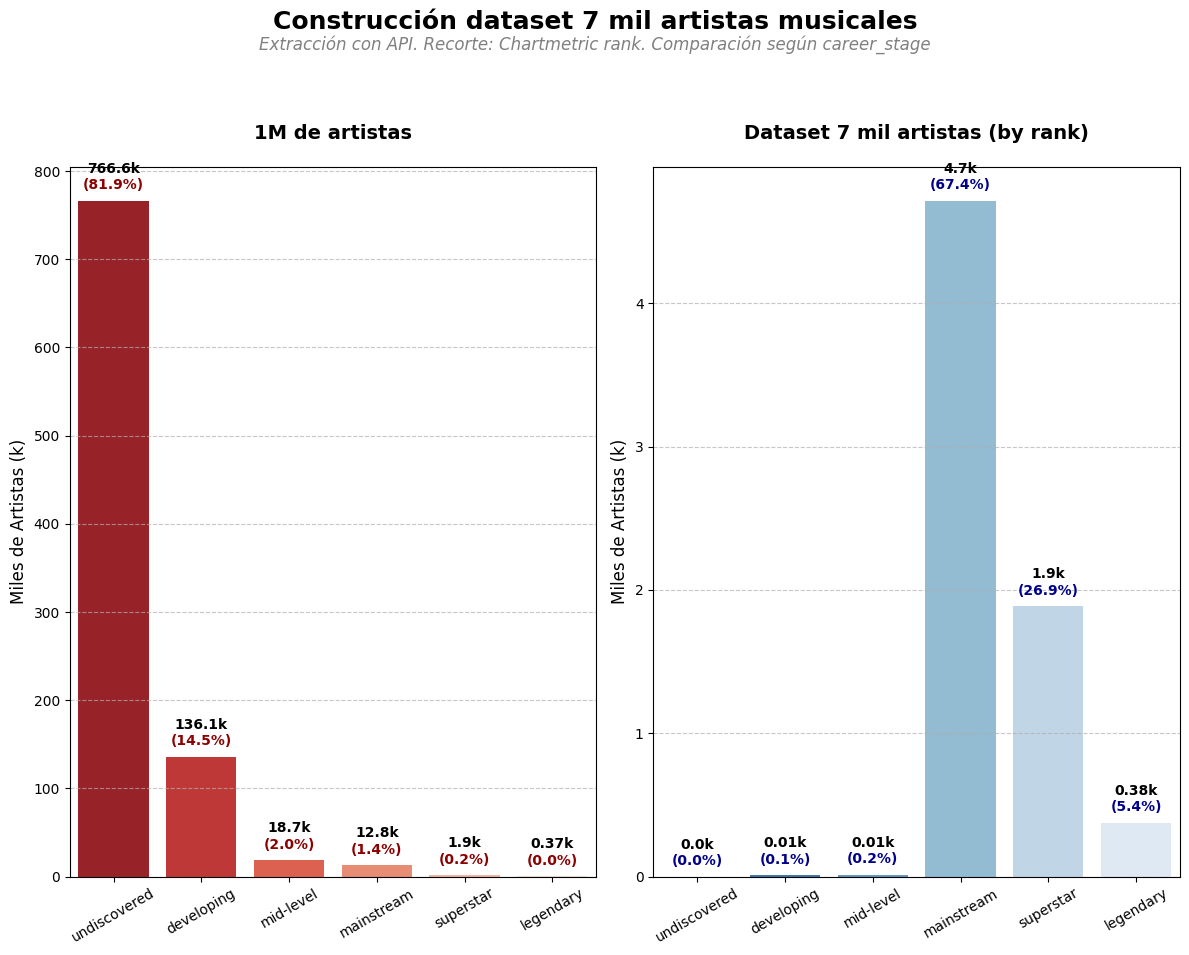

In [391]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Definir orden
orden_focalizado = ['undiscovered', 'developing', 'mid-level', 'mainstream', 'superstar', 'legendary']

def get_clean_stats(df, name):
    temp_series = df["career_stage"].str.lower().str.strip().str.replace(' ', '-')
    counts = temp_series.value_counts()
    total = len(df)
    stats = counts.reindex(orden_focalizado).fillna(0).reset_index()
    stats.columns = ['career_stage', 'count']
    stats['thousands'] = stats['count'] / 1000
    stats['percentage'] = (stats['count'] / total) * 100
    return stats

df1_stats = get_clean_stats(df, 'Original')
df2_stats = get_clean_stats(df_mmequal, 'MMEqual')

# 2. Configuración de la figura
fig, (ax2, ax1) = plt.subplots(1, 2, figsize=(12, 10), sharey=False)

# Títulos
plt.suptitle('Construcción dataset 7 mil artistas musicales', fontsize=18, fontweight='bold', y=0.98)
fig.text(0.5, 0.94, 'Extracción con API. Recorte: Chartmetric rank. Comparación según career_stage', 
         ha='center', fontsize=12, color='gray', style='italic')

# Gráfico 1: Dataset Original (Azules)
sns.barplot(x='career_stage', y='thousands', data=df1_stats, ax=ax1, palette='Blues_r', hue='career_stage', legend=False)
ax1.set_title('Dataset 7 mil artistas (by rank)', fontsize=14, fontweight='bold', pad=20)
ax1.set_ylabel('Miles de Artistas (k)', fontsize=12)
ax1.set_xlabel('')

# Gráfico 2: Dataset MMEqual (Rojos)
sns.barplot(x='career_stage', y='thousands', data=df2_stats, ax=ax2, palette='Reds_r', hue='career_stage', legend=False)
ax2.set_title('1M de artistas', fontsize=14, fontweight='bold', pad=20)
ax2.set_ylabel('Miles de Artistas (k)', fontsize=12)
ax2.set_xlabel('')

# 3. Estética y etiquetas con COLORES DIFERENCIADOS
for i, (ax, stats_df) in enumerate(zip([ax1, ax2], [df1_stats, df2_stats])):
    ax.tick_params(axis='x', rotation=30)
    ax.yaxis.grid(True, linestyle='--', alpha=0.7)
    
    # Definimos el color del porcentaje según el gráfico (i=0 es ax1/Azul, i=1 es ax2/Rojo)
    color_pct = 'darkblue' if i == 0 else 'darkred'
    
    for p, thres, pct in zip(ax.patches, stats_df['thousands'], stats_df['percentage']):
        val_height = p.get_height()
        
        if val_height >= 0:
            k_label = f'{thres:.2f}k' if 0 < thres < 1 else f'{thres:.1f}k'
            
            # 1. Anotamos la cantidad en NEGRO
            ax.annotate(k_label, (p.get_x() + p.get_width() / 2., val_height),
                        ha='center', va='bottom', fontsize=10, fontweight='bold', 
                        color='black', xytext=(0, 18), textcoords='offset points')
            
            # 2. Anotamos el porcentaje en el COLOR de la paleta
            ax.annotate(f'({pct:.1f}%)', (p.get_x() + p.get_width() / 2., val_height),
                        ha='center', va='bottom', fontsize=10, fontweight='bold', 
                        color=color_pct, xytext=(0, 6), textcoords='offset points')

plt.tight_layout(rect=[0, 0.03, 1, 0.92]) 
plt.show()

In [392]:
#!pip install pandas matplotlib seaborn plotly nbformat nbformat>=4.2.0

In [393]:
import sys
!{sys.executable} -m pip install plotly nbformat


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [394]:
# import plotly.graph_objects as go
# from plotly.subplots import make_subplots

# # 1. Definir la figura con títulos de subplots (subplot_titles se encarga de ponerlos arriba)
# fig = make_subplots(
#     rows=1, cols=2, 
#     shared_yaxes=True, 
#     horizontal_spacing=0.07,
#     subplot_titles=("Fuente: 1M artistas", "Dataset 7k artistas") # <--- Títulos arriba
# )

# # Gráfico Izquierda: 1M de artistas (Rojo)
# fig.add_trace(
#     go.Bar(
#         y=labels, x=val2, name='Fuente: 1 millón de artistas',
#         orientation='h',
#         marker=dict(color='rgba(255, 71, 71, 0.7)', line=dict(color='rgba(255, 71, 71, 1.0)', width=2)),
#         customdata=pct2,
#         hovertemplate='<b>%{y}</b><br>Cantidad: %{x}k<br>Porcentaje: %{customdata:.1f}%<extra></extra>',
#         text=[f"{v:.1f}k <br><span style='color:red'>( {p:.1f}% )</span>" for v, p in zip(val2, pct2)],
#         textposition='outside'
#     ), row=1, col=1
# )

# # Gráfico Derecha: Dataset 7k (Azul)
# fig.add_trace(
#     go.Bar(
#         y=labels, x=val1, name='Dataset 7.000 artistas',
#         orientation='h',
#         marker=dict(color='rgba(71, 150, 255, 0.7)', line=dict(color='rgba(71, 150, 255, 1.0)', width=2)),
#         customdata=pct1,
#         hovertemplate='<b>%{y}</b><br>Cantidad: %{x}k<br>Porcentaje: %{customdata:.1f}%<extra></extra>',
#         text=[f"{v:.1f}k <br><span style='color:dodgerblue'>( {p:.1f}% )</span>" for v, p in zip(val1, pct1)],
#         textposition='outside'
#     ), row=1, col=2
# )

# # 2. Configuración estética y ejes
# fig.update_layout(
#     title_text="DATASET ARTISTAS MUSICALES.<br><span style='font-size:13px; color:gray; font-style:italic'>Construcción con API Chartmetric. Recorte: artist rank. <br>Comparación según career_stage</span>",
#     title_x=0.5,
#     template='plotly_dark',
#     showlegend=False,
#     height=750,
#     margin=dict(t=150, b=100, l=100, r=100), # Aumentamos margen superior para los títulos
# )

# # Personalizar ejes X: cuerpo más pequeño (size=10) y color gris (gray)
# fig.update_xaxes(
#     title_text="Miles de artistas", 
#     title_font=dict(size=12, color='gray'), # <--- Aquí ajustas el estilo
#     row=1, col=1, 
#     autorange='reversed'
# )

# fig.update_xaxes(
#     title_text="Miles de artistas", 
#     title_font=dict(size=12, color='gray'), # <--- Lo mismo para el segundo eje
#     row=1, col=2
# )
# # Ajustar tamaño de los títulos de los subplots (arriba)
# fig.update_annotations(font_size=16, font_color="white")

# fig.show()

# # Guarda el gráfico en un archivo local
# fig.write_html("construccion_dataset_bycareerstage.html")

# Feature engineering

## categóricas
discretizar? reagrupar niveles? pasar a factor? transformar?

In [395]:
cols_cat = [
    "country",
    "pronoun_title",
    "career_stage",
    "career_trend",
    "primary_genre"
]

for col in cols_cat:
    print("\n" + "="*50)
    print(f"Variable: {col}")
    
    # cantidad de niveles
    n_levels = df[col].nunique(dropna=True)
    print(f"Niveles únicos: {n_levels}")
    
    # tabla de frecuencias
    freq = df[col].value_counts(dropna=False)
    prop = df[col].value_counts(normalize=True, dropna=False)
    
    resumen = freq.to_frame(name="count")
    resumen["prop"] = prop
    
    print(resumen.head(20))  # top 20 niveles


Variable: country
Niveles únicos: 112
         count      prop
country                 
US        2630  0.375714
GB         700  0.100000
BR         350  0.050000
MX         323  0.046143
IN         295  0.042143
FR         192  0.027429
DE         172  0.024571
CA         157  0.022429
IT         151  0.021571
PR         133  0.019000
KR         130  0.018571
AU         113  0.016143
ID         104  0.014857
ES          99  0.014143
AR          97  0.013857
CO          94  0.013429
JP          93  0.013286
SE          85  0.012143
NG          84  0.012000
NL          82  0.011714

Variable: pronoun_title
Niveles únicos: 11
                   count      prop
pronoun_title                     
he/him              3694  0.527714
they/them           1913  0.273286
she/her             1380  0.197143
she/they               5  0.000714
he/they                2  0.000286
they/them/she/her      1  0.000143
she/he/they            1  0.000143
she/her/he/him         1  0.000143
He/Him + She/Her 

## major_record_label
genero booleana a partir de record_label

In [396]:
df["record_label"].value_counts()


record_label
UMG                                                                                                                                                                                 613
SME                                                                                                                                                                                 519
WMG                                                                                                                                                                                 412
BMG Rights Management                                                                                                                                                                55
Distrokid                                                                                                                                                                            37
T-Series                                                           

In [397]:
# Definimos términos clave para buscar variantes
keywords = ['Universal', 'UMG', 'Sony', 'SME', 'Warner', 'WMG', 'BMG']

# Filtramos valores únicos que contengan alguna de esas palabras (ignorando mayúsculas)
variantes_encontradas = df[df['record_label'].str.contains('|'.join(keywords), na=False, case=False)]['record_label'].unique()

print("Variantes detectadas en el dataset:")
print(variantes_encontradas)

Variantes detectadas en el dataset:
<StringArray>
[                                                                                                                                                                             'UMG',
                                                                                                                                                                              'WMG',
                                                                                                                                                                              'SME',
                                                                                                                                            'Nibiru International/Sony Music Latin',
                                                                                                                                                 'Royalty Records/Sony Music Latin',
                                             

In [398]:
import numpy as np

# 1. Definimos el patrón (incluyendo las variantes que confirmamos)
patron_majors = r'Universal|UMG|Sony|SME|Warner|WMG|BMG'

# 2. Creamos la columna. 
# El truco es 'na=False' dentro de contains para que la máscara sea booleana pura...
mask_majors = df['record_label'].str.contains(patron_majors, case=False, na=False)

# 3. ...pero luego aplicamos los nulos de la columna original usando .loc
df['major_record_label'] = mask_majors.astype(object) # Permitir nulos
df.loc[df['record_label'].isna(), 'major_record_label'] = np.nan

# Verificación de fuego
print(f"Nulos en original: {df['record_label'].isna().sum()}")
print(f"Nulos en nueva: {df['major_record_label'].isna().sum()}")

# Verificación rápida
print(df['major_record_label'].value_counts(dropna=False))

Nulos en original: 524
Nulos en nueva: 524
major_record_label
False    4765
True     1711
NaN       524
Name: count, dtype: int64


## pronoun_short
reagrupo niveles
niveles con n<5: si (they + algo) reagrupo en nivel nuevo: NonBinary/diverse.

In [399]:
df["pronoun_title"].value_counts()


pronoun_title
he/him               3694
they/them            1913
she/her              1380
she/they                5
he/they                 2
they/them/she/her       1
she/he/they             1
she/her/he/him          1
He/Him + She/Her        1
she/her/they/them       1
she/it                  1
Name: count, dtype: int64

In [400]:
nulos_cantidad = df['pronoun_title'].isna().sum()
print(f"La cantidad de nulos es: {nulos_cantidad}")

porcentaje_nulos = df['pronoun_title'].isna().mean() * 100
print(f"Porcentaje de nulos: {porcentaje_nulos}%")

La cantidad de nulos es: 0
Porcentaje de nulos: 0.0%


In [401]:
# Definimos la lista de categorías de interés
pronombres_diversos = ['she/they', 'they/them/she/her', 'she/he/they', 'she/her/he/him', 'He/Him + She/Her', 'he/they', 'she/her/they/them', 'she/it']

# Filtramos el df y seleccionamos la columna del nombre del artista
artistas_lista = df[df['pronoun_title'].isin(pronombres_diversos)][['artist_name', 'pronoun_title']]

print(artistas_lista)

           artist_name      pronoun_title
86              Halsey           she/they
97         Demi Lovato  they/them/she/her
176            Kehlani           she/they
343   Melanie Martinez           she/they
988         Becky Hill           she/they
1028     Pabllo Vittar        she/he/they
2291     Gloria Groove     she/her/he/him
2976     Mother Mother   He/Him + She/Her
3226          Cavetown            he/they
4724     Trisha Paytas  she/her/they/them
5006    Princess Nokia           she/they
5104              Arca             she/it
5461        Gerard Way            he/they


In [402]:
# 1. Creamos la nueva columna como copia de la original
df['pronoun_short'] = df['pronoun_title']

# 2. Definimos la máscara para capturar "Todo lo demás" (Diversidad Real)
# Excluimos he/him, she/her y el they/them (que trataremos como banda/neutral)
mask_diversos = ~df['pronoun_short'].isin(['he/him', 'she/her', 'they/them']) & df['pronoun_short'].notna()

# 3. Asignamos la etiqueta unificada a esos casos
df.loc[mask_diversos, 'pronoun_short'] = 'Non-Binary/Diverse'

# 5. Los nulos los dejamos claros
df['pronoun_short'] = df['pronoun_short'].fillna('Unknown')

# Verificamos el resultado
print("Distribución de la nueva columna 'pronoun_short':")
print(df['pronoun_short'].value_counts())

# 5. Verificamos la diferencia entre la original y la corta
print("--- Comparativa de Columnas ---")
print(f"Categorías originales: {df['pronoun_title'].nunique()}")
print(f"Categorías en pronoun_short: {df['pronoun_short'].nunique()}")
print("\nConteo en la nueva columna:")
print(df['pronoun_short'].value_counts(dropna=False))

Distribución de la nueva columna 'pronoun_short':
pronoun_short
he/him                3694
they/them             1913
she/her               1380
Non-Binary/Diverse      13
Name: count, dtype: int64
--- Comparativa de Columnas ---
Categorías originales: 11
Categorías en pronoun_short: 4

Conteo en la nueva columna:
pronoun_short
he/him                3694
they/them             1913
she/her               1380
Non-Binary/Diverse      13
Name: count, dtype: int64


## genre_short
reagrupo niveles de primary_genre

In [403]:
nulos_cantidad = df['primary_genre'].isna().sum()
print(f"La cantidad de nulos es: {nulos_cantidad}")



La cantidad de nulos es: 0


In [404]:
import pandas as pd

# Con este comando obligamos a Pandas a mostrar TODAS las filas del conteo
with pd.option_context('display.max_rows', None):
    print(df['primary_genre'].value_counts())

primary_genre
pop                           881
hip-hop/rap                   434
r&b/soul                      363
dance                         361
alternative                   280
rock                          263
house                         203
reggaeton                     159
latin pop                     152
country                       144
instrumental                  130
afrobeats                     112
bollywood                     109
electronic                    107
k-pop                          94
hard rock                      87
indonesian pop                 77
mpb                            76
gangsta rap                    74
punjabi                        73
sertanejo                      61
indie                          59
corridos                       55
norteno                        55
regional mexican               53
perreo                         52
italian pop                    52
soundtrack                     51
indie folk                     50


In [405]:
genre_groups = {
    "Pop": [
        "pop", "k-pop", "j-pop", "indie pop", "soft pop", "dance pop", "electropop", 
        "art pop", "teen pop", "dark pop", "vpop", "vietnamese pop", "chinese pop", 
        "spanish pop", "indian pop", "indonesian pop", "french pop", "italian pop", 
        "arabic pop", "playback", "turkish pop", "folk pop", "dark internet pop", 
        "bubblegrunge", "jangle pop", "oldies", "bedroom pop", "new wave", "industrial pop",
        "african pop", "ppop", "russian pop", "brazilian pop",
        "city pop", "progressive pop", "dutch pop", "polish pop",
        "ukrainian pop", "israeli pop", "cpop", "ballad",
        "swedish pop", "bubblegum pop"
    ],

    "Hip-Hop & Trap": [
        "hip-hop/rap", "gangsta rap", "dark trap", "trap", "korean hip-hop/rap",
        "uk drill", "spanish drill", "phonk", "french hip-hop/rap", "french hip-hop", 
        "mexican hip-hop/rap", "brazilian hip-hop/rap", "italian hip-hop", 
        "colombian hip-hop", "spanish hip-hop", "turkish hip-hop", "indian hip-hop/rap", 
        "desi hip-hop", "alternative hip-hop", "electro-hop", "emo rap",
        "brazilian hip-hop", "german hip-hop", "indian hip hop",
        "japanese hip-hop/rap", "egyptian hip-hop/rap", "german hip-hop/rap",
        "nigerian hip-hop", "malayam hip-hop", "moroccan hip-hop",
        "azerbaijani hip-hop/rap", "cloud rap", "drill", "grime", "rap nacional",
        "dutch hip-hop", "russian hip-hop/rap", "pinoy hip-hop", "polish hip-hop",
        "arabic hip-hop", "experimental hip-hop/rap", "nerdcore",
        "nyc drill", "mexican hip-hop", "g-funk", "canadian hip-hop",
        "rage rap", "chinese hip-hop", "uk hip-hop/rap", "indonesian hip-hop/rap",
        "cote d'ivoire hip-hop", "swedish hip-hop", "european hip-hop/rap",
        "boom bap", "balkan hip-hop", "caribbean hip-hop/rap"
    ],

    "Latin & Urban": [
        "reggaeton", "perreo", "urbano latino", "latin pop", "latin rock", "latin folk", 
        "reggae", "dub reggae", "bachata", "salsa", "salsa colombiana", "cumbia ranchera", 
        "dembow dominicano", "trap latino", "latin ballad", "latin indie", "cuarteto", 
        "latin worship", "soca", "latin children's music", "argentine trap", 
        "latin hip-hop/rap", "argentine hip-hop", "argentine rock", "dancehall",
        "latin r&b/soul", "latin", "rkt", "chilean hip-hop", "mexican pop", "trapfunk",
        "cumbia", "dembow", "christian reggaeton", "dominican",
        "chilean reggaeton", "guaracha"
    ],

    "Rock & Metal": [
        "rock", "hard rock", "alternative rock", "metal", "black metal", "german metal",
        "funk metal", "punk", "pop punk", "spanish punk", "shoegaze", "progressive rock", "emo",
        "japanese rock", "post-hardcore", "melodic hardcore", "surf punk",
        "alternative metal", "art rock", "classic rock", "rock and roll", "rocksteady",
        "turkish rock", "hardcore", "metalcore", "math metal",
        "melodic metalcore", "djent", "skramz", "glam rock", "yacht rock",
        "death metal", "russian rock"
    ],

    "Electronic & Dance": [
        "dance", "house", "tech house", "electronic", "trance", "dubstep", "post-disco", 
        "amapiano", "african dance", "ambient",
        "afro house", "hypertechno", "hyperpop", "drum & bass", "edm",
        "acidcore", "rawstyle", "psytrance", "nightcore", "melodic techno",
        "european dance", "brazilian dance", "broken beat",
        "south african deep house", "european electronic", "electronica",
        "fidget house", "kawaii future bass", "vinahouse", "gqom",
        "idm", "hard techno", "mena electronic", "hardgroove",
        "progressive house", "bass", "sped", "glitch",
        "italo disco", "disco", "russian disco", "indian ambient",
        "electroswing", "lounge", "techno", "melodic house",
        "electro house", "hardstyle", "latin house"
    ],

    "R&B, Soul & Funk": [
        "r&b/soul", "r&b", "contemporary r&b/soul", "korean r&b/soul", "indie soul", 
        "funk", "pagode", "brazilian funk", "brazilian phonk", "alternative r&b", "doo wop",
        "soul", "blue-eyed soul", "deep funk"
    ],

    "Regional Mexicano": [
        "regional mexican", "corridos", "corridos tumbados", "norteno", "banda", 
        "grupo", "mexican folk"
    ],

    "Country & Folk": [
        "country", "country pop", "country rock", "country rap", "outlaw country", 
        "texas country", "new country", "indie folk", "singer/songwriter",
        "alt-country", "psychedelic folk", "bluegrass"
    ],

    "Regional Global": [
        "bollywood", "afrobeats", "sertanejo", "forro", "punjabi", "arabic", 
        "tamil", "malayalam", "turkish folk", "indian folk", "nasheed",
        "opm", "dangdut", "malay", "telugu", "pakistani", "japanese",
        "indonesian folk", "rai", "kannadan", "haryanvi", "quebecoise",
        "neomelodic", "musica tropicale", "african worldbeat", 
        "schlager", "mpb",
        "brazilian worship", "thai", "shqip", "mahraganat",
        "nigerian gospel", "israeli", "russian", "bhojpuri",
        "garba", "soukous", "tribal", "flamenco",
        "indian fusion", "maskandi"
    ],

    "Alternative & Indie": [
        "alternative", "indie", "new romantic", "new age", "dream pop", 
        "indonesian indie", "chill", "harsh noise", "christian", "christian pop",
        "christian hip-hop", "german worship", "worship", "gospel",
        "german indie", "spanish indie", "lofi", "corecore",
        "asian underground", "scenecore",
        "australian alternative"
    ],

    "Jazz & Blues & Classical ": [
        "jazz", "blues", "instrumental", "vocal", "acapella", "classical",
        "vocal jazz", "chicago blues", "latin jazz", "orchestral", "big band"
    ],

    "Miscellaneous": [
        "soundtrack", "children's music", "anime", "game-pop", "comedy",
        "louvores", "german children's music", "vocaloid",
        "musical", "brazilian children's music", "german spoken", "holiday",
        "italian children's music", "danish children's music", "chrétien"
    ]
}

In [406]:
# 1. Creamos el mapa invertido 
flattened_map = {item: k for k, v in genre_groups.items() for item in v}

# 2. Pre-procesamos la columna original para asegurar coincidencia
# Es vital pasar a minúsculas y quitar espacios para que coincida con las llaves del diccionario
df['primary_genre_clean'] = df['primary_genre'].str.lower().str.strip()

# 3. Aplicamos el mapeo
df['genre_short'] = df['primary_genre_clean'].map(flattened_map)

# 4. LA CLAVE: Si es NaN (no hubo match), conservamos el valor original de 'primary_genre'
df['genre_short'] = df['genre_short'].fillna(df['primary_genre_clean'])

#  Borramos la columna auxiliar de limpieza
del df['primary_genre_clean']

# Capitalizar todo para que quede estético en los gráficos
df['genre_short'] = df['genre_short'].str.capitalize()


In [407]:
pd.set_option('display.max_rows', None)

print(df['genre_short'].value_counts(dropna=False))

genre_short
Pop                          1435
Electronic & dance            927
Hip-hop & trap                923
Latin & urban                 716
Regional global               638
Rock & metal                  567
R&b, soul & funk              494
Alternative & indie           461
Country & folk                279
Regional mexicano             231
Jazz & blues & classical      180
Miscellaneous                 149
Name: count, dtype: int64


## country_short
reagrupo country a regiones excepto US y GB

In [408]:
nulos_cantidad = df['country'].isna().sum()
print(f"La cantidad de nulos es: {nulos_cantidad}")



La cantidad de nulos es: 67


In [409]:
import pandas as pd

# Con este comando obligamos a Pandas a mostrar TODAS las filas del conteo
with pd.option_context('display.max_rows', None):
    print(df['country'].value_counts())

    

country
US    2630
GB     700
BR     350
MX     323
IN     295
FR     192
DE     172
CA     157
IT     151
PR     133
KR     130
AU     113
ID     104
ES      99
AR      97
CO      94
JP      93
SE      85
NG      84
NL      82
ZA      76
TR      69
PH      62
JM      49
DO      39
NO      30
RU      30
IE      29
VE      28
BE      27
CL      26
DK      19
AT      17
PL      17
GH      17
PK      15
EG      15
CU      15
TH      14
RO      13
VN      11
TZ      11
CN      11
UA      10
NZ       9
PA       9
LB       9
FI       9
CH       9
IL       8
IS       7
CD       7
TW       7
MY       7
UY       6
HK       6
PE       6
MA       5
EC       4
EE       4
CI       4
GT       3
HU       3
SA       3
CZ       3
DZ       3
LT       3
SG       3
IR       3
BB       2
SN       2
MC       2
IQ       2
PS       2
AM       2
ML       2
GR       2
AL       2
HR       2
BY       2
CY       2
MD       2
JO       2
RS       2
LK       2
KG       1
UM       1
GY       1
ZW       1
KZ       1
VG

In [410]:
COUNTRY_GROUPS = {
    # Excepciones de Alta Frecuencia
    'US': 'United States',
    'GB': 'Great Britain',
    
    # North America
    'CA': 'North America_sinUS',
    'VI': 'North America_sinUS',   # U.S. Virgin Islands
    
    # LATAM
    'MX': 'LATAM', 'PR': 'LATAM', 'CO': 'LATAM', 'AR': 'LATAM', 'VE': 'LATAM',
    'DO': 'LATAM', 'CL': 'LATAM', 'CU': 'LATAM', 'UY': 'LATAM', 'PA': 'LATAM',
    'GT': 'LATAM', 'JM': 'LATAM', 'BB': 'LATAM', 'BR': 'LATAM',
    'PE': 'LATAM', 'EC': 'LATAM', 'NI': 'LATAM', 'VG': 'LATAM',
    'AG': 'LATAM', 'SX': 'LATAM',
    'MQ': 'LATAM',
    'TT': 'LATAM',
    
    # Europe_sinGB
    'FR': 'Europe_sinGB', 'SE': 'Europe_sinGB', 'DE': 'Europe_sinGB', 'ES': 'Europe_sinGB',
    'IT': 'Europe_sinGB', 'NL': 'Europe_sinGB', 'IE': 'Europe_sinGB', 'BE': 'Europe_sinGB',
    'NO': 'Europe_sinGB', 'DK': 'Europe_sinGB', 'IS': 'Europe_sinGB', 'RU': 'Europe_sinGB',
    'RO': 'Europe_sinGB', 'AT': 'Europe_sinGB', 'PL': 'Europe_sinGB', 'HU': 'Europe_sinGB',
    'FI': 'Europe_sinGB', 'MC': 'Europe_sinGB', 'CZ': 'Europe_sinGB',
    'UA': 'Europe_sinGB', 'AM': 'Europe_sinGB', 'LT': 'Europe_sinGB', 'EE': 'Europe_sinGB',
    'CH': 'Europe_sinGB', 'GR': 'Europe_sinGB', 'AL': 'Europe_sinGB',
    'HR': 'Europe_sinGB', 'CY': 'Europe_sinGB', 'BY': 'Europe_sinGB',
    'MD': 'Europe_sinGB', 'RS': 'Europe_sinGB',
    'PT': 'Europe_sinGB',
    
    # Asia & Oceania
    'IN': 'Asia & Oceania', 'KR': 'Asia & Oceania', 'AU': 'Asia & Oceania',
    'JP': 'Asia & Oceania', 'ID': 'Asia & Oceania', 'TH': 'Asia & Oceania',
    'NZ': 'Asia & Oceania', 'VN': 'Asia & Oceania', 'PK': 'Asia & Oceania',
    'KG': 'Asia & Oceania', 'TW': 'Asia & Oceania', 'KZ': 'Asia & Oceania',
    'UM': 'Asia & Oceania',
    'PH': 'Asia & Oceania', 'MY': 'Asia & Oceania', 'HK': 'Asia & Oceania',
    'SG': 'Asia & Oceania', 'CN': 'Asia & Oceania',
    'KH': 'Asia & Oceania',
    'LK': 'Asia & Oceania',
    'WS': 'Asia & Oceania',
    
    # Africa & ME
    'NG': 'Africa & ME', 'ZA': 'Africa & ME', 'GH': 'Africa & ME', 'EG': 'Africa & ME',
    'LB': 'Africa & ME', 'TZ': 'Africa & ME', 'ZW': 'Africa & ME', 'SN': 'Africa & ME',
    'CD': 'Africa & ME', 'TR': 'Africa & ME', 'GY': 'Africa & ME',
    'IL': 'Africa & ME', 'QA': 'Africa & ME', 'SA': 'Africa & ME', 'IQ': 'Africa & ME',
    'DZ': 'Africa & ME', 'MA': 'Africa & ME', 'PS': 'Africa & ME',
    'KE': 'Africa & ME', 'CV': 'Africa & ME',
    'ML': 'Africa & ME', 'CI': 'Africa & ME', 'UG': 'Africa & ME', 'BJ': 'Africa & ME',
    'JO': 'Africa & ME', 'ZM': 'Africa & ME', 'KW': 'Africa & ME',
    'SC': 'Africa & ME', 'IR': 'Africa & ME', 'SY': 'Africa & ME', 'TN': 'Africa & ME',
    'MG': 'Africa & ME', 'GA': 'Africa & ME'
}

In [411]:
import pandas as pd
import numpy as np

def process_country(iso_code):
    # 1. Si es NA, lo mantenemos como NA (puedes usar np.nan o 'NA')
    if pd.isna(iso_code):
        return iso_code # Retorna el valor nulo original (NaN)
    
    # Aseguramos que sea string y esté en mayúsculas para la búsqueda
    code_upper = str(iso_code).upper().strip()
    
    # 2. Buscamos en el diccionario. 
    # Si NO existe, devolvemos el código original (code_upper)
    return COUNTRY_GROUPS.get(code_upper, code_upper)

# Aplicar al DataFrame
df['country_short'] = df['country'].apply(process_country)

In [412]:
print(df['country_short'].value_counts(dropna=False))

country_short
United States          2630
LATAM                  1190
Europe_sinGB           1030
Asia & Oceania          887
Great Britain           700
Africa & ME             338
North America_sinUS     158
NaN                      67
Name: count, dtype: int64


In [413]:
df.columns

Index(['chartmetric_id', 'artist_name', 'country', 'pronoun_title',
       'gender_title', 'record_label', 'hometown_city', 'cm_artist_rank',
       'cm_artist_score', 'career_stage', 'career_stage_score', 'career_trend',
       'career_trend_score', 'primary_genre', 'sp_followers',
       'sp_monthly_listeners', 'sp_popularity', 'sp_playlist_total_reach',
       'ins_followers', 'twitter_followers', 'tiktok_followers',
       'tiktok_likes', 'ycs_subscribers', 'ycs_views',
       'youtube_daily_video_views', 'youtube_monthly_video_views',
       'deezer_fans', 'shazam_count', 'pandora_lifetime_streams',
       'pandora_lifetime_stations_added', 'band', 'num_sp_editorial_playlists',
       'num_sp_playlists', 'sp_editorial_playlist_total_reach',
       'num_am_editorial_playlists', 'num_am_playlists',
       'num_de_editorial_playlists', 'num_de_playlists',
       'de_playlist_total_reach', 'de_editorial_playlist_total_reach',
       'num_az_editorial_playlists', 'num_az_playlists',
  

# SIN SHOWS ANALISIS

# muerto_disuelto
dentro de: n_shows_total == na  
identificar los que no podrían tocar (muerto, disuelto, retirado)

API: musicbrainz y wikidata


In [414]:
# Filtramos los que no tienen shows y ordenamos por seguidores de Spotify (u otra métrica de éxito)
sospechosos = df[df['n_shows_total'].isna()].sort_values(by='sp_followers', ascending=False).head(20)

print(sospechosos[['artist_name', 'sp_followers', 'genre_short']])

          artist_name  sp_followers          genre_short
10      Ariana Grande   110377644.0                  Pop
3       Justin Bieber    87773572.0                  Pop
37                BTS    83715320.0                  Pop
6             Rihanna    72295517.0                  Pop
104            Pritam    67166342.0      Regional global
59              Queen    56653833.0         Rock & metal
29       Selena Gomez    53953263.0         Rock & metal
78       XXXTENTACION    53258390.0       Hip-hop & trap
135  Sidhu Moose Wala    48251521.0      Regional global
143        Juice WRLD    44626992.0       Hip-hop & trap
57      One Direction    40902295.0                  Pop
26    Michael Jackson    40089025.0   Electronic & dance
30       Daddy Yankee    38990179.0        Latin & urban
50       Harry Styles    35141599.0                  Pop
138    Arctic Monkeys    33713695.0  Alternative & indie
121       The Beatles    31572529.0         Rock & metal
41                Sia    311860

In [415]:
import pandas as pd
import requests
import time
from pathlib import Path

# ── 1. Filtrar artistas sin shows ──────────────────────────────────────────────
sin_shows = df[df['n_shows_total'].isna() | (df['n_shows_total'] == 0)].copy()
artistas = sin_shows['artist_name'].tolist()
print(f"Artistas sin shows en el universo actual: {len(artistas)}")

# ── 1.b Cache local de resultados ya consultados ───────────────────────────────
CACHE_FILE = Path("cache_muerto_disuelto.csv")

cache_cols = [
    "artista", "died", "death_date", "tipo", "fuente",
    "encontrado", "score", "error", "estado"
]

if CACHE_FILE.exists():
    df_cache = pd.read_csv(CACHE_FILE)
else:
    df_cache = pd.DataFrame(columns=cache_cols)

for col in cache_cols:
    if col not in df_cache.columns:
        df_cache[col] = pd.NA

artistas_ya_consultados = set(df_cache["artista"].dropna().astype(str))

artistas_pendientes = []
for nombre in artistas:
    if pd.notna(nombre):
        nombre = str(nombre)
        if nombre not in artistas_ya_consultados and nombre not in artistas_pendientes:
            artistas_pendientes.append(nombre)

print(f"Artistas ya consultados en cache: {len(artistas_ya_consultados)}")
print(f"Artistas pendientes de consultar: {len(artistas_pendientes)}")

# ── 2. Función MusicBrainz ─────────────────────────────────────────────────────
def check_musicbrainz(nombre):
    """Devuelve dict con died: bool | None, y fuente"""
    url = "https://musicbrainz.org/ws/2/artist/"
    params = {
        "query": f'artist:"{nombre}"',
        "fmt": "json",
        "limit": 1
    }
    headers = {"User-Agent": "ArtistChecker/1.0 (tu@email.com)"}
    
    try:
        r = requests.get(url, params=params, headers=headers, timeout=10)
        r.raise_for_status()
        data = r.json()
        
        artistas_mb = data.get("artists", [])
        if not artistas_mb:
            return {
                "died": None,
                "death_date": None,
                "tipo": None,
                "fuente": "musicbrainz",
                "encontrado": False,
                "score": None,
                "error": None
            }
        
        artista = artistas_mb[0]
        life_span = artista.get("life-span", {})
        ended = life_span.get("ended", False)
        death_date = life_span.get("end", None)
        tipo = artista.get("type", "")
        
        return {
            "died": ended,
            "death_date": death_date,
            "tipo": tipo,
            "fuente": "musicbrainz",
            "encontrado": True,
            "score": artista.get("score", 0),
            "error": None
        }
    except Exception as e:
        return {
            "died": None,
            "death_date": None,
            "tipo": None,
            "fuente": "musicbrainz",
            "encontrado": False,
            "score": None,
            "error": str(e)
        }

# ── 3. Función Wikidata (fallback) ─────────────────────────────────────────────
def check_wikidata(nombre):
    """Busca en Wikidata si el artista tiene fecha de muerte"""
    url = "https://www.wikidata.org/w/api.php"
    
    params_search = {
        "action": "wbsearchentities",
        "search": nombre,
        "language": "es",
        "type": "item",
        "limit": 1,
        "format": "json"
    }
    
    try:
        r = requests.get(url, params=params_search, timeout=10)
        results = r.json().get("search", [])
        if not results:
            return {
                "died": None,
                "death_date": None,
                "tipo": None,
                "fuente": "wikidata",
                "encontrado": False,
                "score": None,
                "error": None
            }
        
        qid = results[0]["id"]
        
        params_entity = {
            "action": "wbgetentities",
            "ids": qid,
            "props": "claims",
            "format": "json"
        }
        r2 = requests.get(url, params=params_entity, timeout=10)
        claims = r2.json()["entities"][qid].get("claims", {})
        
        death_claim = claims.get("P570", [])
        if death_claim:
            death_date = death_claim[0]["mainsnak"]["datavalue"]["value"]["time"]
            return {
                "died": True,
                "death_date": death_date,
                "tipo": None,
                "fuente": "wikidata",
                "encontrado": True,
                "score": None,
                "error": None
            }
        else:
            return {
                "died": False,
                "death_date": None,
                "tipo": None,
                "fuente": "wikidata",
                "encontrado": True,
                "score": None,
                "error": None
            }
    
    except Exception as e:
        return {
            "died": None,
            "death_date": None,
            "tipo": None,
            "fuente": "wikidata",
            "encontrado": False,
            "score": None,
            "error": str(e)
        }

# ── 4. Loop principal con fallback solo para pendientes ───────────────────────
resultados = []

for nombre in artistas_pendientes:
    res = check_musicbrainz(nombre)
    
    if not res["encontrado"]:
        time.sleep(0.5)
        res = check_wikidata(nombre)
    
    res["artista"] = nombre
    resultados.append(res)
    
    time.sleep(1.1)

print("Consultas nuevas finalizadas")

# ── 5. Armar DataFrame de resultados nuevos ────────────────────────────────────
df_nuevos = pd.DataFrame(resultados)

if df_nuevos.empty:
    df_nuevos = pd.DataFrame(columns=cache_cols)

for col in cache_cols:
    if col not in df_nuevos.columns:
        df_nuevos[col] = pd.NA

# ── 6. Clasificar solo lo nuevo ────────────────────────────────────────────────
def clasificar(row):
    if not row["encontrado"]:
        return "no_encontrado"
    if row["died"] == True:
        return "muerto_o_disuelto"
    if row["died"] == False:
        return "activo_o_vivo"
    return "incierto"

if len(df_nuevos) > 0:
    df_nuevos["estado"] = df_nuevos.apply(clasificar, axis=1)

# ── 7. Actualizar cache ────────────────────────────────────────────────────────
df_cache = pd.concat([df_cache, df_nuevos], ignore_index=True)

for col in cache_cols:
    if col not in df_cache.columns:
        df_cache[col] = pd.NA

df_cache = df_cache.drop_duplicates(subset=["artista"], keep="last")
df_cache.to_csv(CACHE_FILE, index=False)

print(f"Cache guardado en: {CACHE_FILE.resolve()}")
print(f"Total artistas acumulados en cache: {len(df_cache)}")

# ── 8. df_resultados para el universo actual del run ───────────────────────────
df_resultados = df_cache[df_cache["artista"].isin(artistas)].copy()

# Recalcular estado si hubiera filas viejas sin esa columna
if "estado" not in df_resultados.columns:
    df_resultados["estado"] = df_resultados.apply(clasificar, axis=1)
else:
    mask_estado_na = df_resultados["estado"].isna()
    if mask_estado_na.any():
        df_resultados.loc[mask_estado_na, "estado"] = (
            df_resultados.loc[mask_estado_na].apply(clasificar, axis=1)
        )

print(df_resultados["estado"].value_counts(dropna=False))

Artistas sin shows en el universo actual: 2947
Artistas ya consultados en cache: 2945
Artistas pendientes de consultar: 0
Consultas nuevas finalizadas
Cache guardado en: C:\Users\Silvana\Documents\Maestria_Exactas\taller_tesis_1\music_industry_social_live_code\cache_muerto_disuelto.csv
Total artistas acumulados en cache: 2945
estado
incierto             2052
muerto_o_disuelto     621
no_encontrado         271
Name: count, dtype: int64


In [416]:
print("\n--- Detalles adicionales de los hallazgos ---")

print("\nTotal de registros analizados:")
print(len(df))

print("\nCantidad de artistas con n_shows_total NA:")
print(df['n_shows_total'].isna().sum())

print("\nCantidad de artistas con n_shows_total = 0:")
print((df['n_shows_total'] == 0).sum())

print("\nCantidad de artistas con shows positivos:")
print((df['n_shows_total'] > 0).sum())

print("\nTop 10 artistas con mayor cantidad de shows:")
print(df.sort_values('n_shows_total', ascending=False)[['artist_name','n_shows_total']].head(10))

print("\nDistribución básica de n_shows_total:")
print(df['n_shows_total'].describe())


--- Detalles adicionales de los hallazgos ---

Total de registros analizados:
7000

Cantidad de artistas con n_shows_total NA:
2947

Cantidad de artistas con n_shows_total = 0:
0

Cantidad de artistas con shows positivos:
4053

Top 10 artistas con mayor cantidad de shows:
                     artist_name  n_shows_total
1115                  Air Supply          179.0
3427                  Cem Adrian          178.0
4532              Robert Glasper          175.0
5109                 Aaron Lewis          170.0
6348                 Marcus King          169.0
719               The Beach Boys          164.0
6312  Chicago Symphony Orchestra          163.0
474                       ZZ Top          160.0
1742              Warren Zeiders          155.0
84                   Teddy Swims          152.0

Distribución básica de n_shows_total:
count    4053.000000
mean       29.454972
std        30.251680
min         1.000000
25%         5.000000
50%        20.000000
75%        45.000000
max       17

In [417]:
df_inciertos = df_resultados[df_resultados["estado"] == "incierto"]
print(df_inciertos["score"].describe())
print(df_inciertos["score"].value_counts().sort_index())

count     2052.0
unique       1.0
top        100.0
freq      2052.0
Name: score, dtype: float64
score
100.0    2052
Name: count, dtype: int64


In [418]:
# Armar df de trabajo con id para merge seguro
df_target = df[df['n_shows_total'].isna() | (df['n_shows_total'] == 0)][
    ['chartmetric_id', 'artist_name', 'country', 'gender_title', 
     'band', 'primary_genre', 'career_stage', 'sp_followers', 
     'sp_monthly_listeners', 'cm_artist_rank']
].copy()

# Agregar nombre limpio para merge con resultados
df_resultados['artista'] = df_resultados['artista']  # ya existe

# Merge por nombre (temporal hasta tener id en resultados)
df_explore = df_target.merge(
    df_resultados[['artista', 'estado', 'death_date', 'tipo', 'fuente', 'score']],
    left_on='artist_name',
    right_on='artista',
    how='left'
).drop(columns='artista')

print(df_explore['estado'].value_counts())
print(df_explore.groupby(['career_stage', 'estado']).size().unstack(fill_value=0))

# Resumen por estado
print(df_explore['estado'].value_counts())
print(f"\nBands en muerto_o_disuelto: {df_explore[(df_explore['estado']=='muerto_o_disuelto') & (df_explore['band']==True)].shape[0]}")
print(f"Persons en muerto_o_disuelto: {df_explore[(df_explore['estado']=='muerto_o_disuelto') & (df_explore['band']==False)].shape[0]}")

estado
incierto             2055
muerto_o_disuelto     621
no_encontrado         271
Name: count, dtype: int64
estado        incierto  muerto_o_disuelto  no_encontrado
career_stage                                            
developing           3                  1              3
legendary           42                130              6
mainstream        1562                411            225
mid-level            8                  2              1
superstar          440                 77             36
estado
incierto             2055
muerto_o_disuelto     621
no_encontrado         271
Name: count, dtype: int64

Bands en muerto_o_disuelto: 218
Persons en muerto_o_disuelto: 403


### merge muertos + manuales

Dentro de: n_shows_total == na, 
si encontrado: muerto_disuelto == True
si no fue encontrado: muerto_disuelto == NA
Fuera de n_shows_total == na, es decir n_shows_total > 0 ,
entonces muerto_disuelto == false


In [419]:
# 1. Preparar resultados con la lógica de estados
import numpy as np

def aplicar_estado(row):
    if row['estado'] == 'muerto_o_disuelto':
        return True
    elif row['estado'] == 'no_encontrado':
        return pd.NA
    else:
        return False

df_resultados['muerto_disuelto'] = df_resultados.apply(aplicar_estado, axis=1)

# 2. Armar df_target
df_target = df[df['n_shows_total'].isna() | (df['n_shows_total'] == 0)][
    ['chartmetric_id', 'artist_name']
].copy()

# 3. Merge por nombre
df_merge = df_target.merge(
    df_resultados[['artista', 'muerto_disuelto', 'death_date', 'tipo']],
    left_on='artist_name',
    right_on='artista',
    how='left'
).drop(columns='artista')

# 4. Imputación manual (aquí forzamos True a los IDs específicos)
ids_muertos_manual = [
    207587,   # Frédéric Chopin
    104611,   # Pyotr Ilyich Tchaikovsky
    114488,   # R. D. Burman
    153284,   # Ariel Camacho y Los Plebes Del Rancho
    206358,   # Los Plebes del Rancho de Ariel Camacho
    207661,   # Smokey Robinson & The Miracles
    172267,   # Steely Dan
    19423,    # Sergei Rachmaninoff
    1528,     # The Jackson 5
    369,      # Steppenwolf
    47,       # Phil Collins    
    283,      # Mazzy Star 
    214788,   # Her's 
    126185,   # La Unión 
    109446,   # Las Ketchup 
    311136    # Aviões do Forró
]
df_merge.loc[df_merge['chartmetric_id'].isin(ids_muertos_manual), 'muerto_disuelto'] = True

# 5. Limpiar columna si ya existe en df (para poder re-correr sin duplicados)
for col in ['muerto_disuelto', 'death_date', 'tipo']:
    if col in df.columns:
        df = df.drop(columns=col)

# 6. Merge final a df por chartmetric_id (clave segura)
df = df.merge(
    df_merge[['chartmetric_id', 'muerto_disuelto', 'death_date', 'tipo']],
    on='chartmetric_id',
    how='left'
)

# 7. Artistas con shows → False
mask_tiene_shows = df['n_shows_total'] > 0
df.loc[mask_tiene_shows, 'muerto_disuelto'] = df.loc[mask_tiene_shows, 'muerto_disuelto'].fillna(False)

# 8. Limpiar columnas auxiliares
df = df.drop(columns=['tipo', 'death_date'])

# Verificación
print(df['muerto_disuelto'].value_counts(dropna=False))
print(f"Nulos restantes: {df['muerto_disuelto'].isna().sum()}")
print(f"Shape df: {df.shape}")

muerto_disuelto
False    6100
True      637
<NA>      263
Name: count, dtype: int64
Nulos restantes: 263
Shape df: (7000, 82)


In [420]:
# Verificar que los NaN en muerto_disuelto tienen n_shows_total > 0
nulos = df[df['muerto_disuelto'].isna()]

print(f"Registros con muerto_disuelto nulo: {len(nulos)}")
print(f"De esos, con n_shows_total > 0: {(nulos['n_shows_total'] > 0).sum()}")
print(f"De esos, con n_shows_total == 0 o nulo: {(nulos['n_shows_total'].isna() | (nulos['n_shows_total'] == 0)).sum()}")

Registros con muerto_disuelto nulo: 263
De esos, con n_shows_total > 0: 0
De esos, con n_shows_total == 0 o nulo: 263


In [421]:
# Los que tienen shows → False (están vivos)
df['muerto_disuelto'] = df['muerto_disuelto'].fillna(False)

# Verificación final
print(df['muerto_disuelto'].value_counts())
print(f"Nulos restantes: {df['muerto_disuelto'].isna().sum()}")

muerto_disuelto
False    6363
True      637
Name: count, dtype: int64
Nulos restantes: 0


## analizo resto
muerto == False, 

In [422]:
df_sin_shows = df[
    (df['n_shows_total'].isna()) 
][['chartmetric_id', 'artist_name', 'country', 'band', 'primary_genre',
   'career_stage', 'sp_followers', 'sp_monthly_listeners', 'cm_artist_rank',
   'muerto_disuelto']
].sort_values('career_stage').reset_index(drop=True)

print(f"Total: {len(df_sin_shows)} artistas")
print(df_sin_shows['career_stage'].value_counts())

Total: 2947 artistas
career_stage
mainstream    2198
superstar      553
legendary      178
mid-level       11
developing       7
Name: count, dtype: int64


### SAVE sin shows

In [423]:
# df_sin_shows.to_csv('sin_shows.csv', index=False)
# print(" Exportado")

In [424]:
df_sin_shows_top = df[
    (df['n_shows_total'].isna()) &
    (df['career_stage'].isin(['mainstream', 'superstar', 'legendary']))
][['chartmetric_id', 'artist_name', 'country', 'band', 'primary_genre',
   'career_stage', 'sp_followers', 'sp_monthly_listeners', 'cm_artist_rank',
   'muerto_disuelto']
].sort_values('career_stage').reset_index(drop=True)

print(f"Total: {len(df_sin_shows_top)} artistas")
print(df_sin_shows_top['career_stage'].value_counts())


Total: 2929 artistas
career_stage
mainstream    2198
superstar      553
legendary      178
Name: count, dtype: int64


In [425]:
# display(df_sin_shows_top)

### SAVE sin shows top career

In [426]:
# df_sin_shows_top.to_csv('sin_shows_top_career.csv', index=False)
# print(" Exportado")

# SHOWS 2026
incorporo el resultado de la detección realizada en otra notebook sobre el conjunto de artistas n_shows_total == NA

In [427]:
# 9. Cargar output de chequeo 2026 y quedarse solo con lo necesario
df_2026 = pd.read_csv(
    r"C:\Users\Silvana\Documents\Maestria_Exactas\taller_tesis_1\music_industry_social_live_code\sin_shows_2026_checked_clean.csv"
)

df_2026 = df_2026[["chartmetric_id", "n_shows_2026", "shows_2026"]].copy()

# 10. Asegurar unicidad por chartmetric_id en el archivo 2026
df_2026["chartmetric_id"] = pd.to_numeric(df_2026["chartmetric_id"], errors="coerce")
df_2026 = df_2026.dropna(subset=["chartmetric_id"]).copy()
df_2026["chartmetric_id"] = df_2026["chartmetric_id"].astype(int)

df_2026 = df_2026.drop_duplicates(subset=["chartmetric_id"], keep="last")

# 11. Limpiar columnas previas en df para poder re-correr sin duplicados
for col in ["n_shows_2026", "shows_2026"]:
    if col in df.columns:
        df = df.drop(columns=col)

# 12. Merge por chartmetric_id
df["chartmetric_id"] = pd.to_numeric(df["chartmetric_id"], errors="coerce")
df = df.merge(
    df_2026,
    on="chartmetric_id",
    how="left"
)

# 13. Regla de imputación: si shows_2026 == True, entonces muerto_disuelto = False
df.loc[df["shows_2026"] == True, "muerto_disuelto"] = False

# 14. Verificaciones rápidas
print("Conteo shows_2026:")
print(df["shows_2026"].value_counts(dropna=False))
print()

print("Conteo n_shows_2026 no nulos:")
print(df["n_shows_2026"].notna().sum())
print()

print("Conteo muerto_disuelto:")
print(df["muerto_disuelto"].value_counts(dropna=False))
print()

print("Casos con shows_2026 == True y muerto_disuelto != False:")
display(
    df.loc[
        (df["shows_2026"] == True) & (df["muerto_disuelto"] != False),
        ["chartmetric_id", "artist_name", "shows_2026", "n_shows_2026", "muerto_disuelto"]
    ].head(20)
)

print(f"Shape df: {df.shape}")

Conteo shows_2026:
shows_2026
NaN     6777
True     223
Name: count, dtype: int64

Conteo n_shows_2026 no nulos:
223

Conteo muerto_disuelto:
muerto_disuelto
False    6363
True      637
Name: count, dtype: int64

Casos con shows_2026 == True y muerto_disuelto != False:


,chartmetric_id,artist_name,shows_2026,n_shows_2026,muerto_disuelto


Shape df: (7000, 84)


# OFF CYCLE
off_cycle = True
n_shows_total es NA
shows_2026 == True
muerto_disuelto != True
off_cycle = False
n_shows_total > 0
o muerto_disuelto == True
off_cycle = NA
el resto
Es decir, los casos donde:
no hubo shows en 2024–2025 observados
no hubo shows 2026 confirmados
no están marcados como muertos/disueltos

In [428]:
# ==========================================
# CONSTRUCCIÓN DE off_cycle
# ==========================================

import pandas as pd

# Definición conceptual:
# off_cycle = artista sin shows observados en 2024-2025 (n_shows_total NA)
#             pero con evidencia de actividad live en 2026 (shows_2026 == True)

df["off_cycle"] = pd.NA

# TRUE: sin shows 2024-2025 observados, pero con shows confirmados en 2026
mask_off_cycle_true = (
    df["n_shows_total"].isna() &
    (df["shows_2026"] == True) &
    (df["muerto_disuelto"] != True)
)

# FALSE: tuvo shows en 2024-2025 o está muerto/disuelto
mask_off_cycle_false = (
    (df["n_shows_total"].fillna(0) > 0) |
    (df["muerto_disuelto"] == True)
)

df.loc[mask_off_cycle_true, "off_cycle"] = True
df.loc[mask_off_cycle_false, "off_cycle"] = False

print("Conteo off_cycle:")
print(df["off_cycle"].value_counts(dropna=False))

print("\nChequeo de consistencia:")
print("off_cycle = True y n_shows_total no NA:",
      ((df["off_cycle"] == True) & df["n_shows_total"].notna()).sum())

print("off_cycle = True y shows_2026 != True:",
      ((df["off_cycle"] == True) & (df["shows_2026"] != True)).sum())

print("\nEjemplos off_cycle = True:")
display(
    df.loc[
        df["off_cycle"] == True,
        ["artist_name", "chartmetric_id", "n_shows_total", "shows_2026", "muerto_disuelto"]
    ].head(20)
)

Conteo off_cycle:
off_cycle
False    4690
<NA>     2087
True      223
Name: count, dtype: int64

Chequeo de consistencia:
off_cycle = True y n_shows_total no NA: 0
off_cycle = True y shows_2026 != True: 0

Ejemplos off_cycle = True:


,artist_name,chartmetric_id,n_shows_total,shows_2026,muerto_disuelto
10,Ariana Grande,3963,NaN,True,False
37,BTS,206557,NaN,True,False
50,Harry Styles,558681,NaN,True,False
60,Romeo Santos,3973,NaN,True,False
61,JAY-Z,58,NaN,True,False
80,Madonna,27,NaN,True,False
167,A$AP Rocky,4015,NaN,True,False
180,Disney,303089,NaN,True,False
206,Céline Dion,43,NaN,True,False
235,The Neighbourhood,4298,NaN,True,False


# asigno 0 y NA
si muerto_disuelto == True
    o off_cycle == True

→ entonces
    shows 2024–2025 = 0
    métricas derivadas = NA

In [429]:
# ==========================================
# IMPUTACIÓN BLOQUE LIVE
# muerto_disuelto y off_cycle
# ==========================================

cols_cero = [
    'n_shows_2024', 'n_shows_with_capacity_2024', 'n_cities_2024',
    'n_countries_2024', 'n_currencies_2024',
    'n_shows_2025', 'n_shows_with_capacity_2025', 'n_cities_2025',
    'n_countries_2025', 'n_currencies_2025',
    'n_shows_total', 'n_shows_with_capacity_total',
    'n_cities_total', 'n_countries_total'
]

cols_na = [
    'avg_low_price_2024', 'avg_high_price_2024', 'avg_venue_capacity_2024',
    'total_capacity_2024', 'shows_per_country_2024', 'main_currency_2024',
    'avg_low_price_2025', 'avg_high_price_2025', 'avg_venue_capacity_2025',
    'total_capacity_2025', 'shows_per_country_2025', 'main_currency_2025',
    'avg_venue_capacity_total', 'total_capacity_total',
    'shows_per_country_total'
]

# solo columnas existentes
cols_cero = [c for c in cols_cero if c in df.columns]
cols_na = [c for c in cols_na if c in df.columns]

mask_muertos = df['muerto_disuelto'] == True
mask_offcycle = df['off_cycle'] == True

mask_imputacion = mask_muertos | mask_offcycle

# imputación para 2024–2025
df.loc[mask_imputacion, cols_cero] = 0
df.loc[mask_imputacion, cols_na] = pd.NA

# coherencia adicional SOLO para muertos
if 'shows_2026' in df.columns:
    df.loc[mask_muertos, 'shows_2026'] = False

# Verificación
print("muertos:", mask_muertos.sum())
print("off_cycle:", mask_offcycle.sum())

print("\nChequeo imputación:")
print((df.loc[mask_imputacion, 'n_shows_total'] == 0).sum())

display(
    df.loc[mask_imputacion,
        ['artist_name','chartmetric_id','muerto_disuelto','off_cycle','n_shows_total','shows_2026']
    ].head(20)
)

muertos: 637
off_cycle: 223

Chequeo imputación:
860


,artist_name,chartmetric_id,muerto_disuelto,off_cycle,n_shows_total,shows_2026
10,Ariana Grande,3963,False,True,0.0,True
26,Michael Jackson,178,True,False,0.0,False
37,BTS,206557,False,True,0.0,True
50,Harry Styles,558681,False,True,0.0,True
57,One Direction,3747,True,False,0.0,False
59,Queen,72,True,False,0.0,False
60,Romeo Santos,3973,False,True,0.0,True
61,JAY-Z,58,False,True,0.0,True
78,XXXTENTACION,74419,True,False,0.0,False
80,Madonna,27,False,True,0.0,True


In [430]:
df[
    (df["muerto_disuelto"] == True) &
    (df["n_shows_total"] > 0)
]

,chartmetric_id,artist_name,country,pronoun_title,gender_title,record_label,hometown_city,cm_artist_rank,cm_artist_score,career_stage,...,n_countries_total,shows_per_country_total,major_record_label,pronoun_short,genre_short,country_short,muerto_disuelto,n_shows_2026,shows_2026,off_cycle


# HAS LIVE DATA

In [431]:
# ==========================================
# CONSTRUCCIÓN DE has_live_data (Lógica Corregida)
# ==========================================

# 1. Definimos la máscara para 2024-2025
# "0 o mayor a 0" significa simplemente que el valor NO sea nulo.
mask_live_2024_2025 = df["n_shows_total"].notna()

# 2. Definimos la máscara para 2026
# Al ser 'object', comparamos contra el booleano y contra el string "True" por seguridad
mask_live_2026 = (df["shows_2026"] == True) | (df["shows_2026"] == "True")

# 3. Asignación inicial (OR lógico)
df["has_live_data"] = mask_live_2024_2025 | mask_live_2026

# 4. Coherencia: si está muerto/disuelto, forzamos False
# (Ajustado para detectar tanto booleano como string)
mask_muerto = (df["muerto_disuelto"] == True) | (df["muerto_disuelto"] == "True")
df.loc[mask_muerto, "has_live_data"] = False

# 5. Aseguramos que el resto sea False y no quede como NA
df["has_live_data"] = df["has_live_data"].fillna(False).astype(bool)

# --- Verificación ---
print(f"Total True en has_live_data: {df['has_live_data'].sum()}")

Total True en has_live_data: 4276


In [432]:
# ==========================================
# DIAGNÓSTICO DE BLOQUE LIVE + FLAGS
# ==========================================

import pandas as pd
import numpy as np

live_cols = [
    "n_shows_2024",
    "n_shows_2025",
    "n_shows_total",
    "n_shows_with_capacity_2024",
    "n_shows_with_capacity_2025",
    "n_shows_with_capacity_total",
    "n_cities_2024",
    "n_cities_2025",
    "n_cities_total",
    "n_countries_2024",
    "n_countries_2025",
    "n_countries_total",
    "avg_venue_capacity_2024",
    "avg_venue_capacity_2025",
    "avg_venue_capacity_total",
    "total_capacity_2024",
    "total_capacity_2025",
    "total_capacity_total",
    "shows_per_country_2024",
    "shows_per_country_2025",
    "shows_per_country_total"
]

extra_cols = [
    "n_shows_2026",
    "shows_2026",
    "muerto_disuelto",
    "off_cycle",
    "has_live_data"
]

live_cols = [c for c in live_cols if c in df.columns]
extra_cols = [c for c in extra_cols if c in df.columns]

print("===================================")
print("1) RESUMEN GENERAL")
print("===================================")

print("Total filas:", len(df))
print()

print("Resumen n_shows_total:")
print(df["n_shows_total"].describe())
print()

print("n_shows_total - NA:", df["n_shows_total"].isna().sum())
print("n_shows_total - cero:", (df["n_shows_total"] == 0).sum())
print("n_shows_total - >0:", (df["n_shows_total"].fillna(0) > 0).sum())
print()

if "shows_2026" in df.columns:
    print("Distribución shows_2026:")
    print(df["shows_2026"].value_counts(dropna=False))
    print()

if "off_cycle" in df.columns:
    print("Distribución off_cycle:")
    print(df["off_cycle"].value_counts(dropna=False))
    print()

if "muerto_disuelto" in df.columns:
    print("Distribución muerto_disuelto:")
    print(df["muerto_disuelto"].value_counts(dropna=False))
    print()

if "has_live_data" in df.columns:
    print("Distribución has_live_data:")
    print(df["has_live_data"].value_counts(dropna=False))
    print()


print("===================================")
print("2) FILAS CON n_shows_total = NA")
print("===================================")

mask_na_shows = df["n_shows_total"].isna()

print("Cantidad de filas con n_shows_total = NA:")
print(mask_na_shows.sum())
print()

print("Nulos dentro del bloque live, restringido a filas con n_shows_total = NA:")
print(df.loc[mask_na_shows, live_cols].isna().sum().sort_values())
print()

print("Columnas del bloque live con algún valor no NA cuando n_shows_total es NA:")
cols_con_info_parcial = df.loc[mask_na_shows, live_cols].notna().sum()
print(cols_con_info_parcial[cols_con_info_parcial > 0].sort_values(ascending=False))
print()

for col in ["shows_2026", "off_cycle", "muerto_disuelto", "has_live_data"]:
    if col in df.columns:
        print(f"Distribución de {col} dentro de n_shows_total = NA:")
        print(df.loc[mask_na_shows, col].value_counts(dropna=False))
        print()


print("===================================")
print("3) CASOS INCONSISTENTES")
print("===================================")

# A. n_shows_total = NA pero otra variable del bloque live no NA
mask_inconsistente_live = (
    df["n_shows_total"].isna() &
    df[live_cols].drop(columns=["n_shows_total"]).notna().any(axis=1)
)

print("n_shows_total = NA pero alguna otra variable live no NA:")
print(mask_inconsistente_live.sum())
print()

# B. muerto_disuelto = True y shows_2026 = True
if {"muerto_disuelto", "shows_2026"}.issubset(df.columns):
    mask_muerto_con_2026 = (
        (df["muerto_disuelto"] == True) &
        (df["shows_2026"] == True)
    )
    print("muerto_disuelto = True y shows_2026 = True:")
    print(mask_muerto_con_2026.sum())
    print()
else:
    mask_muerto_con_2026 = pd.Series(False, index=df.index)

# C. muerto_disuelto = True y n_shows_total > 0
if {"muerto_disuelto", "n_shows_total"}.issubset(df.columns):
    mask_muerto_con_shows = (
        (df["muerto_disuelto"] == True) &
        (df["n_shows_total"].fillna(0) > 0)
    )
    print("muerto_disuelto = True y n_shows_total > 0:")
    print(mask_muerto_con_shows.sum())
    print()
else:
    mask_muerto_con_shows = pd.Series(False, index=df.index)

# D. off_cycle = True pero shows_2026 != True
if {"off_cycle", "shows_2026"}.issubset(df.columns):
    mask_offcycle_inconsistente = (
        (df["off_cycle"] == True) &
        (df["shows_2026"] != True)
    )
    print("off_cycle = True pero shows_2026 != True:")
    print(mask_offcycle_inconsistente.sum())
    print()
else:
    mask_offcycle_inconsistente = pd.Series(False, index=df.index)

# E. has_live_data = False pero hay evidencia live
if {"has_live_data", "n_shows_total", "shows_2026"}.issubset(df.columns):
    mask_flag_inconsistente = (
        (df["has_live_data"] == False) &
        (
            (df["n_shows_total"].fillna(0) > 0) |
            (df["shows_2026"] == True)
        )
    )
    print("has_live_data = False pero n_shows_total > 0 o shows_2026 = True:")
    print(mask_flag_inconsistente.sum())
    print()
else:
    mask_flag_inconsistente = pd.Series(False, index=df.index)

mask_any_inconsistencia = (
    mask_inconsistente_live |
    mask_muerto_con_2026 |
    mask_muerto_con_shows |
    mask_offcycle_inconsistente |
    mask_flag_inconsistente
)

if mask_any_inconsistencia.sum() > 0:
    cols_mostrar = [
        c for c in [
            "artist_name", "chartmetric_id",
            "n_shows_total", "n_shows_2026", "shows_2026",
            "muerto_disuelto", "off_cycle", "has_live_data"
        ] + live_cols
        if c in df.columns
    ]
    print("Ejemplos de inconsistencias:")
    display(df.loc[mask_any_inconsistencia, cols_mostrar].head(20))


print("===================================")
print("4) CASOS CON EVIDENCIA DE LIVE")
print("===================================")

mask_con_live = (
    (df["n_shows_total"].fillna(0) > 0) |
    (df["shows_2026"] == True)
)

print("Cantidad de filas con evidencia de live:")
print(mask_con_live.sum())
print()

cols_check = [c for c in live_cols + extra_cols if c in df.columns]
print("Nulos en columnas relevantes dentro de casos con evidencia de live:")
print(df.loc[mask_con_live, cols_check].isna().sum().sort_values())
print()


print("===================================")
print("5) TABLA RESUMEN FINAL")
print("===================================")

resumen = pd.DataFrame({
    "total_filas": [len(df)],
    "n_shows_total_na": [df["n_shows_total"].isna().sum()],
    "n_shows_total_cero": [(df["n_shows_total"] == 0).sum()],
    "n_shows_total_mayor_0": [(df["n_shows_total"].fillna(0) > 0).sum()],
    "shows_2026_true": [(df["shows_2026"] == True).sum() if "shows_2026" in df.columns else pd.NA],
    "off_cycle_true": [(df["off_cycle"] == True).sum() if "off_cycle" in df.columns else pd.NA],
    "muerto_disuelto_true": [(df["muerto_disuelto"] == True).sum() if "muerto_disuelto" in df.columns else pd.NA],
    "has_live_data_true": [(df["has_live_data"] == True).sum() if "has_live_data" in df.columns else pd.NA],
    "inconsistente_live_block": [mask_inconsistente_live.sum()],
    "muerto_con_shows_total": [mask_muerto_con_shows.sum()],
    "muerto_con_shows_2026": [mask_muerto_con_2026.sum()],
    "offcycle_inconsistente": [mask_offcycle_inconsistente.sum()],
    "flag_live_inconsistente": [mask_flag_inconsistente.sum()]
})

display(resumen)

1) RESUMEN GENERAL
Total filas: 7000

Resumen n_shows_total:
count    4913.000000
mean       24.299003
std        29.668945
min         0.000000
25%         1.000000
50%        13.000000
75%        38.000000
max       179.000000
Name: n_shows_total, dtype: float64

n_shows_total - NA: 2087
n_shows_total - cero: 860
n_shows_total - >0: 4053

Distribución shows_2026:
shows_2026
NaN      6140
False     637
True      223
Name: count, dtype: int64

Distribución off_cycle:
off_cycle
False    4690
<NA>     2087
True      223
Name: count, dtype: int64

Distribución muerto_disuelto:
muerto_disuelto
False    6363
True      637
Name: count, dtype: int64

Distribución has_live_data:
has_live_data
True     4276
False    2724
Name: count, dtype: int64

2) FILAS CON n_shows_total = NA
Cantidad de filas con n_shows_total = NA:
2087

Nulos dentro del bloque live, restringido a filas con n_shows_total = NA:
n_shows_2024                   2087
n_shows_2025                   2087
n_shows_total            

,total_filas,n_shows_total_na,n_shows_total_cero,n_shows_total_mayor_0,shows_2026_true,off_cycle_true,muerto_disuelto_true,has_live_data_true,inconsistente_live_block,muerto_con_shows_total,muerto_con_shows_2026,offcycle_inconsistente,flag_live_inconsistente
0,7000,2087,860,4053,223,223,637,4276,0,0,0,0,0


# SAVE post FE all columns

In [367]:
#nombre_archivo = "dataset_fe_2903.csv" 
#nombre_archivo = "dataset_fe_4403.csv" 

nombre_archivo = "dataset_fe_7000.csv" 

df.to_csv(nombre_archivo, index=False, encoding='utf-8-sig')

print(f" Archivo '{nombre_archivo}' guardado con éxito en carpeta de trabajo.")

 Archivo 'dataset_fe_7000.csv' guardado con éxito en carpeta de trabajo.


In [368]:
df.columns

Index(['chartmetric_id', 'artist_name', 'country', 'pronoun_title',
       'gender_title', 'record_label', 'hometown_city', 'cm_artist_rank',
       'cm_artist_score', 'career_stage', 'career_stage_score', 'career_trend',
       'career_trend_score', 'primary_genre', 'sp_followers',
       'sp_monthly_listeners', 'sp_popularity', 'sp_playlist_total_reach',
       'ins_followers', 'twitter_followers', 'tiktok_followers',
       'tiktok_likes', 'ycs_subscribers', 'ycs_views',
       'youtube_daily_video_views', 'youtube_monthly_video_views',
       'deezer_fans', 'shazam_count', 'pandora_lifetime_streams',
       'pandora_lifetime_stations_added', 'band', 'num_sp_editorial_playlists',
       'num_sp_playlists', 'sp_editorial_playlist_total_reach',
       'num_am_editorial_playlists', 'num_am_playlists',
       'num_de_editorial_playlists', 'num_de_playlists',
       'de_playlist_total_reach', 'de_editorial_playlist_total_reach',
       'num_az_editorial_playlists', 'num_az_playlists',
  

# Conjuntos columnas

In [369]:
# --- definicion de subconjuntos de columnas del dataframe ---

cols_metadata = [
    'chartmetric_id', 'artist_name', 'country', 'pronoun_title',
    'gender_title', 'record_label', 'hometown_city', 'cm_artist_rank',
    'cm_artist_score', 'career_stage', 'career_stage_score', 'career_trend',
    'career_trend_score', 'primary_genre', 'band', 'major_record_label',
    'pronoun_short', 'genre_short', 'country_short', 'muerto_disuelto',
]

cols_streaming = [
    'sp_followers', 'sp_monthly_listeners', 'sp_popularity',
    'sp_playlist_total_reach', 'deezer_fans', 'shazam_count',
    'pandora_lifetime_streams', 'pandora_lifetime_stations_added',
]

cols_redes_sociales = [
    'ins_followers', 'twitter_followers', 'tiktok_followers',
    'tiktok_likes', 'tiktok_top_video_views',
    'tiktok_top_video_comments', 'tiktok_track_posts',
]

cols_youtube = [
    'ycs_subscribers', 'ycs_views',
    'youtube_daily_video_views', 'youtube_monthly_video_views',
]

cols_playlists = [
    'num_sp_editorial_playlists', 'num_sp_playlists',
    'sp_editorial_playlist_total_reach', 'num_am_editorial_playlists',
    'num_am_playlists', 'num_de_editorial_playlists', 'num_de_playlists',
    'de_playlist_total_reach', 'de_editorial_playlist_total_reach',
    'num_az_editorial_playlists', 'num_az_playlists',
    'num_yt_editorial_playlists', 'num_yt_playlists',
    'yt_playlist_total_reach',
]

cols_concerts = [
    'n_shows_2024', 'avg_low_price_2024', 'avg_high_price_2024',
    'avg_venue_capacity_2024', 'total_capacity_2024',
    'n_shows_with_capacity_2024', 'n_cities_2024', 'n_countries_2024',
    'n_currencies_2024', 'main_currency_2024', 'n_shows_2025',
    'avg_low_price_2025', 'avg_high_price_2025', 'avg_venue_capacity_2025',
    'total_capacity_2025', 'n_shows_with_capacity_2025', 'n_cities_2025',
    'n_countries_2025', 'n_currencies_2025', 'main_currency_2025',
    'shows_per_country_2025', 'shows_per_country_2024', 'n_shows_total',
    'n_shows_with_capacity_total', 'total_capacity_total',
    'avg_venue_capacity_total', 'n_cities_total', 'n_countries_total',
    'shows_per_country_total', 'n_shows_2026', 'shows_2026',
    'off_cycle', 'has_live_data',
]

# --- diccionario con todos los grupos, util para iteracion ---
col_groups = {
    'metadata':       cols_metadata,
    'streaming':      cols_streaming,
    'redes_sociales': cols_redes_sociales,
    'youtube':        cols_youtube,
    'playlists':      cols_playlists,
    'concerts':       cols_concerts,
}

In [370]:
# --- verificacion de cobertura de columnas ---

cols_asignadas = [col for group in col_groups.values() for col in group]

cols_sin_asignar = [col for col in df.columns if col not in cols_asignadas]
cols_fantasma    = [col for col in cols_asignadas if col not in df.columns]

if cols_sin_asignar:
    print("columnas del df no asignadas a ningun grupo:")
    for col in cols_sin_asignar:
        print(f"  - {col}")
else:
    print("todas las columnas del df estan asignadas.")

if cols_fantasma:
    print("columnas asignadas que no existen en el df:")
    for col in cols_fantasma:
        print(f"  - {col}")

todas las columnas del df estan asignadas.


In [371]:
cols_excluir_tabla = [
    'chartmetric_id', 'artist_name', 'pronoun_title',
    'gender_title', 'cm_artist_rank',
    'cm_artist_score', 'career_stage', 'career_stage_score', 'career_trend',
    'career_trend_score'

]

In [372]:
df.shape

(7000, 86)

# TIPOS

In [373]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 86 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   chartmetric_id                     7000 non-null   int64  
 1   artist_name                        7000 non-null   str    
 2   country                            6933 non-null   str    
 3   pronoun_title                      7000 non-null   str    
 4   gender_title                       2439 non-null   str    
 5   record_label                       6476 non-null   str    
 6   hometown_city                      4392 non-null   str    
 7   cm_artist_rank                     7000 non-null   int64  
 8   cm_artist_score                    7000 non-null   float64
 9   career_stage                       7000 non-null   str    
 10  career_stage_score                 7000 non-null   int64  
 11  career_trend                       7000 non-null   str    
 12  car

In [374]:
cols_interes = ['has_live_data', 'major_record_label', 'shows_2026', 'off_cycle', 'muerto_disuelto']

for col in cols_interes:
    print(f"--- Valores únicos en: {col} ---")
    # dropna=False es clave para ver si hay NAs realmente
    print(df[col].value_counts(dropna=False))
    print("\n")

--- Valores únicos en: has_live_data ---
has_live_data
True     4276
False    2724
Name: count, dtype: int64


--- Valores únicos en: major_record_label ---
major_record_label
False    4765
True     1711
NaN       524
Name: count, dtype: int64


--- Valores únicos en: shows_2026 ---
shows_2026
NaN      6140
False     637
True      223
Name: count, dtype: int64


--- Valores únicos en: off_cycle ---
off_cycle
False    4690
<NA>     2087
True      223
Name: count, dtype: int64


--- Valores únicos en: muerto_disuelto ---
muerto_disuelto
False    6363
True      637
Name: count, dtype: int64




# string a factor o float
menos artist_name

In [298]:
import pandas as pd
import numpy as np

# --- 1. Definición de grupos ---
# 'shows_2026' es la flag (NA -> 0)
# 'muerto_disuelto' y 'off_cycle' van a float (con NaN)
cols_bool_con_na = ['muerto_disuelto', 'off_cycle', 'major_record_label']
col_flag = 'shows_2026'
cols_excluidas = ['artist_name']

# --- 2. Tratamiento de la columna FLAG ---
# Primero nos aseguramos de que sea float y llenamos NAs
df[col_flag] = df[col_flag].fillna(False).astype(int).astype(float)

# --- 3. Conversión de booleanas con NA a float ---
# Forzamos conversión a float para que soporte NaN sin problemas
for col in cols_bool_con_na:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# --- 4. Conversión a Categoría ---
# IMPORTANTE: Incluimos tanto 'object' como 'str' para evitar el error de selección
cols_a_category = [
    col for col in df.select_dtypes(include=['object', 'str']).columns
    if col not in cols_excluidas + cols_bool_con_na + [col_flag]
]
df[cols_a_category] = df[cols_a_category].astype('category')

# --- 5. Control Final ---
print("### Reporte de Tipos Final ###")
print(f"Columnas convertidas a categoría: {len(cols_a_category)}")
print(f"Estado de artist_name: {df['artist_name'].dtype}")
print(f"Nulos en muerto_disuelto: {df['muerto_disuelto'].isna().sum()}")
print(f"Valores en shows_2026 (flag): \n{df[col_flag].value_counts()}")

# Verificación de si quedó algún 'object' o 'str' intruso
restantes = df.select_dtypes(include=['object', 'str']).columns.tolist()
print(f"\nColumnas que permanecen como texto: {restantes}")

### Reporte de Tipos Final ###
Columnas convertidas a categoría: 0
Estado de artist_name: str
Nulos en muerto_disuelto: 0
Valores en shows_2026 (flag): 
shows_2026
0.0    6777
1.0     223
Name: count, dtype: int64

Columnas que permanecen como texto: ['artist_name']


# ANALISIS GLOBAL

In [307]:
import sys
!{sys.executable} -m pip install xlsxwriter

  Using cached xlsxwriter-3.2.9-py3-none-any.whl.metadata (2.7 kB)
Using cached xlsxwriter-3.2.9-py3-none-any.whl (175 kB)



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [308]:
import xlsxwriter
print(xlsxwriter.__version__)

3.2.9


In [309]:
import pandas as pd
import numpy as np

# --- Configuraciones previas ---
cols_excluir_tabla = ['artist_name']

def generar_diccionario_datos(df, grupos_dict, excluir):
    reporte = []
    
    # Invertimos el diccionario de grupos para búsqueda rápida {columna: nombre_grupo}
    mapa_grupos = {col: grupo for grupo, lista in grupos_dict.items() for col in lista}
    
    for col in df.columns:
        if col in excluir:
            continue
            
        series = df[col]
        total = len(series)
        nas = series.isna().sum()
        
        # Identificar grupo
        grupo_pertenencia = mapa_grupos.get(col, 'Otros')
        
        # Diccionario base con métricas comunes
        resumen = {
            'Grupo': grupo_pertenencia,
            'Feature': col,
            'Tipo': str(series.dtype),
            'Cant_NA': nas,
            '%_NA': f"{(nas / total * 100):.2f}%",
            'Cant_0': (series == 0).sum() if pd.api.types.is_numeric_dtype(series) else "-",
            '%_0': f"{((series == 0).sum() / total * 100):.2f}%" if pd.api.types.is_numeric_dtype(series) else "-",
            'Mínimo': "-", 'Máximo': "-", 'Media': "-", 'Niveles_Cat': "-",
            'SI (True)': "-", 'NO (False)': "-"
        }

        # --- Lógica por Tipo ---
        
        # 1. Numéricas (Excluimos booleanas explícitas)
        if pd.api.types.is_numeric_dtype(series) and not pd.api.types.is_bool_dtype(series):
            # Caso especial: Booleanas que convertimos a float (0, 1, NaN)
            valores_unicos = series.dropna().unique()
            if set(valores_unicos).issubset({0, 1, 0.0, 1.0}):
                si = (series == 1).sum()
                no = (series == 0).sum()
                resumen['Tipo'] = 'Booleana (0/1)'
                resumen['SI (True)'] = f"{si} ({(si/total*100):.2f}%)"
                resumen['NO (False)'] = f"{no} ({(no/total*100):.2f}%)"
            else:
                resumen['Mínimo'] = series.min()
                resumen['Máximo'] = series.max()
                resumen['Media'] = f"{series.mean():.2f}"

        # 2. Categorías o Strings
        elif isinstance(series.dtype, pd.CategoricalDtype) or series.dtype in ['object', 'str']:
            resumen['Niveles_Cat'] = series.nunique()
            try:
                resumen['Mínimo'] = series.dropna().min()
                resumen['Máximo'] = series.dropna().max()
            except:
                pass

        # 3. Booleanas nativas (bool)
        elif pd.api.types.is_bool_dtype(series):
            si = series.sum()
            no = total - nas - si
            resumen['SI (True)'] = f"{si} ({(si/total*100):.2f}%)"
            resumen['NO (False)'] = f"{no} ({(no/total*100):.2f}%)"

        reporte.append(resumen)
    
    return pd.DataFrame(reporte)

# --- Ejecución y Exportación ---
df_final_reporte = generar_diccionario_datos(df, col_groups, cols_excluir_tabla)

# Ordenar por Grupo para que el Excel sea legible
df_final_reporte = df_final_reporte.sort_values(['Grupo', 'Feature'])

nombre_archivo = "Reporte_Estructura_Dataset.xlsx"
with pd.ExcelWriter(nombre_archivo, engine='xlsxwriter') as writer:
    df_final_reporte.to_excel(writer, sheet_name='Features', index=False)
    
    # Formateo estético
    workbook  = writer.book
    worksheet = writer.sheets['Features']
    
    # Colores por grupo para diferenciar visualmente
    header_format = workbook.add_format({'bold': True, 'bg_color': '#2F75B5', 'font_color': 'white', 'border': 1})
    
    for col_num, value in enumerate(df_final_reporte.columns.values):
        worksheet.write(0, col_num, value, header_format)
        worksheet.set_column(col_num, col_num, 20)

print(f"✅ Tabla exportable generada: {nombre_archivo}")

✅ Tabla exportable generada: Reporte_Estructura_Dataset.xlsx


# HASTA ACA 14-4-26

# df_select
quito las columnas que no quiero usar

## elijo columnas

In [ ]:
cols_excluir_tabla = [
    'chartmetric_id', 'artist_name', 'pronoun_title',
    'gender_title', 'cm_artist_rank',
    'cm_artist_score', 'career_stage', 'career_stage_score', 'career_trend',
    'career_trend_score'

]

In [62]:
# 1. Definimos la lista de columnas a eliminar
cols_to_exclude = [
    'artist_gender', 'cm_artist_score', 
    'avg_low_price_2024', 'avg_high_price_2024', 'main_currency_2024', 
    'avg_low_price_2025', 'avg_high_price_2025', 'main_currency_2025', 
    'hometown_city', 'n_currencies_2025', 'n_currencies_2024', 
    'gender_title', 'record_label', 'primary_genre', 'country', 'pronoun_title'
]

# nuevo DataFrame restando esas columnas
# Usamos errors='ignore' por si alguna columna ya fue borrada antes 
df_select = df.drop(columns=cols_to_exclude, errors='ignore')

print(f"Columnas originales: {df.shape[1]}")
print(f"Columnas en df_select: {df_select.shape[1]}")
print(df_select.columns.tolist())

Columnas originales: 86
Columnas en df_select: 71
['chartmetric_id', 'artist_name', 'cm_artist_rank', 'career_stage', 'career_stage_score', 'career_trend', 'career_trend_score', 'sp_followers', 'sp_monthly_listeners', 'sp_popularity', 'sp_playlist_total_reach', 'ins_followers', 'twitter_followers', 'tiktok_followers', 'tiktok_likes', 'ycs_subscribers', 'ycs_views', 'youtube_daily_video_views', 'youtube_monthly_video_views', 'deezer_fans', 'shazam_count', 'pandora_lifetime_streams', 'pandora_lifetime_stations_added', 'band', 'num_sp_editorial_playlists', 'num_sp_playlists', 'sp_editorial_playlist_total_reach', 'num_am_editorial_playlists', 'num_am_playlists', 'num_de_editorial_playlists', 'num_de_playlists', 'de_playlist_total_reach', 'de_editorial_playlist_total_reach', 'num_az_editorial_playlists', 'num_az_playlists', 'num_yt_editorial_playlists', 'num_yt_playlists', 'yt_playlist_total_reach', 'tiktok_top_video_views', 'tiktok_top_video_comments', 'tiktok_track_posts', 'n_shows_2024',

In [63]:
df_select.shape

(7000, 71)

## Nan

In [64]:
# 1. Configuramos pandas para que muestre todas las filas del resultado
import pandas as pd
pd.set_option('display.max_rows', None)

# 2. resumen ordenado
resumen_nulos = pd.DataFrame({
    'Nulos (Cant)': df_select.isna().sum(),
    'Porcentaje (%)': (df_select.isna().sum() / len(df_select) * 100).round(2)
})

# 3. Ordenamos de mayor a menor nulos
resumen_nulos_ordenado = resumen_nulos.sort_values(by='Nulos (Cant)', ascending=False)

print("Resumen de NAs en df_select (Ordenado):")
print(resumen_nulos_ordenado)

#  Resetear la configuración de visualización
pd.reset_option('display.max_rows')

Resumen de NAs en df_select (Ordenado):
                                   Nulos (Cant)  Porcentaje (%)
n_shows_2026                               6777           96.81
shows_2026                                 6140           87.71
total_capacity_2024                        4005           57.21
avg_venue_capacity_2024                    4005           57.21
shows_per_country_2024                     3816           54.51
avg_venue_capacity_2025                    3526           50.37
total_capacity_2025                        3526           50.37
shows_per_country_2025                     3375           48.21
avg_venue_capacity_total                   3130           44.71
total_capacity_total                       3130           44.71
shows_per_country_total                    2975           42.50
youtube_monthly_video_views                2716           38.80
youtube_daily_video_views                  2716           38.80
tiktok_likes                               2199           31.41


In [65]:
import pandas as pd
pd.set_option('display.max_rows', None)

def contar_unknowns(df):
    unknown_counts = {}
    for col in df.columns:
        if df[col].dtype == object:
            mask = df[col].astype(str).str.lower().str.strip() == 'unknown'
            unknown_counts[col] = mask.sum()
        else:
            unknown_counts[col] = 0
    return unknown_counts

unknowns = contar_unknowns(df_select)

resumen = pd.DataFrame({
    'Nulos (Cant)':   df_select.isna().sum(),
    'Nulos (%)':      (df_select.isna().sum() / len(df_select) * 100).round(2),
    'Ceros (Cant)':   (df_select == 0).sum(),
    'Ceros (%)':      ((df_select == 0).sum() / len(df_select) * 100).round(2),
    'Unknown (Cant)': pd.Series(unknowns),
    'Unknown (%)':    (pd.Series(unknowns) / len(df_select) * 100).round(2),
})

resumen = resumen.sort_values('Nulos (Cant)', ascending=False)
resumen_filtrado = resumen[
    (resumen['Nulos (Cant)'] > 0) | 
    (resumen['Unknown (Cant)'] > 0)
]

print(f"df_select: {len(df_select)} registros | {df_select.shape[1]} columnas")
print(f"Columnas con algún problema: {len(resumen_filtrado)} de {df_select.shape[1]}\n")
print(resumen_filtrado.to_string())

pd.reset_option('display.max_rows')

df_select: 7000 registros | 71 columnas
Columnas con algún problema: 59 de 71

                                   Nulos (Cant)  Nulos (%)  Ceros (Cant)  Ceros (%)  Unknown (Cant)  Unknown (%)
n_shows_2026                               6777      96.81             0       0.00               0          0.0
shows_2026                                 6140      87.71           637       9.10               0          0.0
total_capacity_2024                        4005      57.21             0       0.00               0          0.0
avg_venue_capacity_2024                    4005      57.21             0       0.00               0          0.0
shows_per_country_2024                     3816      54.51             0       0.00               0          0.0
avg_venue_capacity_2025                    3526      50.37             1       0.01               0          0.0
total_capacity_2025                        3526      50.37             1       0.01               0          0.0
shows_per_country

# EDA
ojo circularidad
eliminar rank x ej

clusterización
luego predicción
pensar...

Fanbase vs Engagement

FANBASE / ENGAGEMENT
social / music / live
rank y career stage se basan en social y music


discovery → Instagram / TikTok
consumption → Spotify / YouTube
monetization → streaming + live shows

GRAFICO
línea 1  → global recorded music revenue (IFPI)
línea 2  → live music revenue (PwC / Pollstar)

noe quiero perder pregunta por género. pronouns


Fan Base
Platforms
Spotify, Instagram, YouTube,
Soundcloud, Deezer, TikTok,
Twitter, Pandora, Apple Music,
Amazon Music, Facebook, Twitch

Metricsa
Followers, playlists/editorial playlists,
subscribers, fans, lifetime stations
added, artist track posts

Engagement 
Platforms
Spotify, YouTube, TikTok,
Shazam, Twitter, Instagram,
radio airplay, Pandora, Apple
Music, Amazon Music, Deezer,
Wikipedia, Boomplay, Facebook

Metrics:
Streams, monthly listeners, monthly
video views, channel views, retweets,
likes, page views, talks,
playlists/editorial playlists, artist track
posts, average likes, comments, and
views

# n_shows DISTRIBUCIÓN

In [66]:
cols = ["n_shows_2024", "n_shows_2025", "n_shows_total"]

stats_sin_ceros = []

for c in cols:
    s = df.loc[df[c] > 0, c]

    stats_sin_ceros.append({
        "columna": c,
        "n_con_shows": s.shape[0],
        "min": s.min(),
        "p25": s.quantile(0.25),
        "p50": s.quantile(0.50),
        "p75": s.quantile(0.75),
        "p90": s.quantile(0.90),
        "p95": s.quantile(0.95),
        "mean": s.mean(),
        "max": s.max(),
        "suma_shows": s.sum()
    })

stats_sin_ceros_df = pd.DataFrame(stats_sin_ceros)

print("Shows sin NA y sin 0 (muertos_disueltos) ")
display(stats_sin_ceros_df)

Shows sin NA y sin 0 (muertos_disueltos) 


,columna,n_con_shows,min,p25,p50,p75,p90,p95,mean,max,suma_shows
0,n_shows_2024,3212,1.0,3.0,8.0,21.0,36.0,43.0,13.957659,90.0,44832.0
1,n_shows_2025,3679,1.0,4.0,13.0,31.0,50.0,64.0,20.263387,129.0,74549.0
2,n_shows_total,4053,1.0,5.0,20.0,45.0,74.0,92.0,29.454972,179.0,119381.0


In [67]:
cols = ["n_shows_2024", "n_shows_2025", "n_shows_total"]

check = []

for c in cols:
    check.append({
        "columna": c,
        "NA": df[c].isna().sum(),
        "ceros": (df[c] == 0).sum(),
        "suma_shows": df[c].sum()
    })

check_df = pd.DataFrame(check)

print("Chequeo por columna")
display(check_df)

print("\nChequeo de consistencia de totales")

sum_2024 = df["n_shows_2024"].sum()
sum_2025 = df["n_shows_2025"].sum()
sum_total = df["n_shows_total"].sum()

print("suma_2024:", sum_2024)
print("suma_2025:", sum_2025)
print("suma_total:", sum_total)

print("\n¿2024 + 2025 = total?")
print(sum_2024 + sum_2025 == sum_total)

Chequeo por columna


,columna,NA,ceros,suma_shows
0,n_shows_2024,2087,1701,44832.0
1,n_shows_2025,2087,1234,74549.0
2,n_shows_total,2087,860,119381.0



Chequeo de consistencia de totales
suma_2024: 44832.0
suma_2025: 74549.0
suma_total: 119381.0

¿2024 + 2025 = total?
True


## legendary shows na

In [68]:
display(
    df[
        (df["career_stage"] == "legendary") &
        (df["n_shows_total"].isna())
    ][
        [
            "artist_name",
            "cm_artist_rank",
            "sp_monthly_listeners",
            "sp_followers"
        ]
    ]
    .sort_values("cm_artist_rank")
)

,artist_name,cm_artist_rank,sp_monthly_listeners,sp_followers
155,U2,216,22700001.0,13949004.0
610,Juan Luis Guerra 4.40,458,16613234.0,6578062.0
603,Anu Malik,488,20025708.0,6512024.0
728,Tracy Chapman,831,15404905.0,2156133.0
881,K. S. Chithra,1006,15826782.0,11094001.0
1218,Traditional,1010,7051268.0,110295.0
1677,Javed Akhtar,1033,11900413.0,672939.0
1185,Kenny Loggins,1126,9102476.0,1317602.0
1153,Taina,1233,871.0,267.0
1092,Enya,1302,8474846.0,2767246.0


### cuántos shows na y vivos

In [69]:
df_na_vivos = df[
    df["n_shows_total"].isna() &
    (df["muerto_disuelto"] == False)
].copy()

print("Artistas con n_shows_total NA y no muertos/disueltos:", len(df_na_vivos))

Artistas con n_shows_total NA y no muertos/disueltos: 2087


## candidatos off cycle

In [70]:
print("\n--- Distribución de cm_artist_rank ---")
print(df_na_vivos["cm_artist_rank"].describe())

print("\nPercentiles de cm_artist_rank:")
print(df_na_vivos["cm_artist_rank"].quantile([0.01, 0.05, 0.10, 0.25, 0.50]))

print("\nTop artistas por mejor rank (más cercanos a 1):")
display(
    df_na_vivos[["artist_name","cm_artist_rank","sp_monthly_listeners"]]
    .sort_values("cm_artist_rank")
    .head(20)
)

print("\n--- Distribución de sp_monthly_listeners ---")
print(df_na_vivos["sp_monthly_listeners"].describe())

print("\nPercentiles de sp_monthly_listeners:")
print(df_na_vivos["sp_monthly_listeners"].quantile([0.50, 0.75, 0.90, 0.95, 0.99]))

print("\nArtistas con más monthly listeners:")
display(
    df_na_vivos[["artist_name","cm_artist_rank","sp_monthly_listeners"]]
    .sort_values("sp_monthly_listeners", ascending=False)
    .head(20)
)


--- Distribución de cm_artist_rank ---
count      2087.000000
mean       9460.436033
std       18699.695949
min           3.000000
25%        3640.500000
50%        6796.000000
75%       10127.500000
max      458903.000000
Name: cm_artist_rank, dtype: float64

Percentiles de cm_artist_rank:
0.01     193.86
0.05    1001.60
0.10    1642.60
0.25    3640.50
0.50    6796.00
Name: cm_artist_rank, dtype: float64

Top artistas por mejor rank (más cercanos a 1):


,artist_name,cm_artist_rank,sp_monthly_listeners
3,Justin Bieber,3,98686785.0
6,Rihanna,5,106488383.0
29,Selena Gomez,35,40545353.0
30,Daddy Yankee,38,64211765.0
43,Miley Cyrus,39,53597431.0
41,Sia,40,63758568.0
5725,Le Thien Hieu,70,1009244.0
81,Britney Spears,71,46365380.0
136,Jung Kook,80,15595094.0
92,Bebe Rexha,85,36723980.0



--- Distribución de sp_monthly_listeners ---
count    2.071000e+03
mean     3.826901e+06
std      6.129950e+06
min      1.000000e+00
25%      7.675960e+05
50%      2.370555e+06
75%      4.605681e+06
max      1.064884e+08
Name: sp_monthly_listeners, dtype: float64

Percentiles de sp_monthly_listeners:
0.50     2370555.0
0.75     4605681.0
0.90     8393430.0
0.95    13185216.0
0.99    24712753.3
Name: sp_monthly_listeners, dtype: float64

Artistas con más monthly listeners:


,artist_name,cm_artist_rank,sp_monthly_listeners
6,Rihanna,5,106488383.0
3,Justin Bieber,3,98686785.0
30,Daddy Yankee,38,64211765.0
41,Sia,40,63758568.0
138,Arctic Monkeys,148,54766738.0
43,Miley Cyrus,39,53597431.0
81,Britney Spears,71,46365380.0
104,Pritam,193,46208282.0
29,Selena Gomez,35,40545353.0
189,Frank Ocean,168,39316072.0


In [71]:
rank_umbral = 800
listeners_umbral = 7000000

df_offcycle_candidates = df_na_vivos[
    ((df_na_vivos["cm_artist_rank"] <= rank_umbral) &
    (df_na_vivos["sp_monthly_listeners"] >= listeners_umbral))
].copy()

print("Candidatos off-cycle:", len(df_offcycle_candidates))

display(
    df_offcycle_candidates[
        [
            "artist_name",
            "cm_artist_rank",
            "career_stage",
            "sp_monthly_listeners",
            "sp_followers",
            "country",
            "primary_genre"
        ]
    ]
    .sort_values(
        by=["career_stage", "sp_monthly_listeners", "cm_artist_rank"],
        ascending=[True, False, True]
    )
    .head(50)
)

Candidatos off-cycle: 59


,artist_name,cm_artist_rank,career_stage,sp_monthly_listeners,sp_followers,country,primary_genre
155,U2,216,legendary,22700001.0,13949004.0,IE,rock
603,Anu Malik,488,legendary,20025708.0,6512024.0,IN,bollywood
610,Juan Luis Guerra 4.40,458,legendary,16613234.0,6578062.0,DO,reggaeton
2769,Mayur Puri,494,mainstream,7404935.0,556955.0,IN,bollywood
6,Rihanna,5,superstar,106488383.0,72295517.0,BB,pop
3,Justin Bieber,3,superstar,98686785.0,87773572.0,CA,pop
30,Daddy Yankee,38,superstar,64211765.0,38990179.0,PR,reggaeton
41,Sia,40,superstar,63758568.0,31186073.0,AU,new age
138,Arctic Monkeys,148,superstar,54766738.0,33713695.0,GB,indie
43,Miley Cyrus,39,superstar,53597431.0,27322296.0,US,pop


## sp_monthly_listeners vs n_shows_total

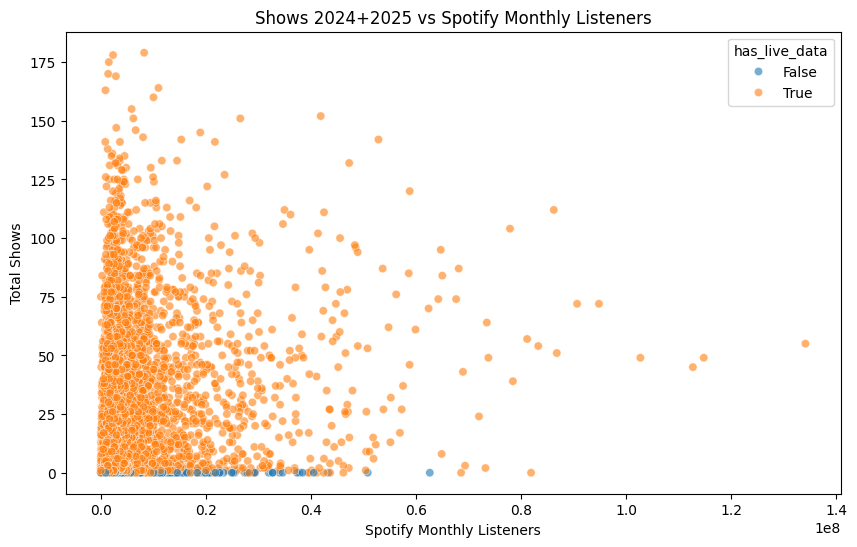

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df_select,
    x="sp_monthly_listeners",
    y="n_shows_total",
    hue="has_live_data",
    alpha=0.6
)

plt.xlabel("Spotify Monthly Listeners")
plt.ylabel("Total Shows")
plt.title("Shows 2024+2025 vs Spotify Monthly Listeners")

plt.show()

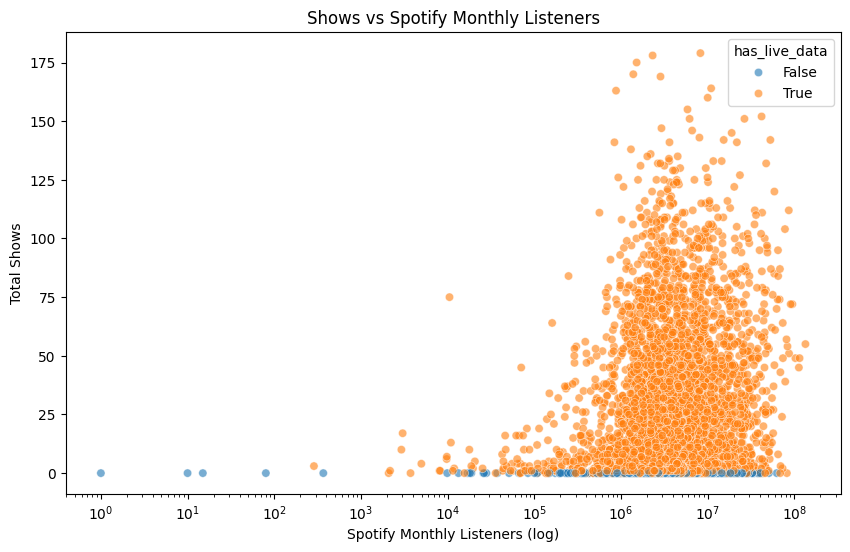

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df_select,
    x="sp_monthly_listeners",
    y="n_shows_total",
    hue="has_live_data",
    alpha=0.6
)

plt.xscale("log")

plt.xlabel("Spotify Monthly Listeners (log)")
plt.ylabel("Total Shows")
plt.title("Shows vs Spotify Monthly Listeners")

plt.show()

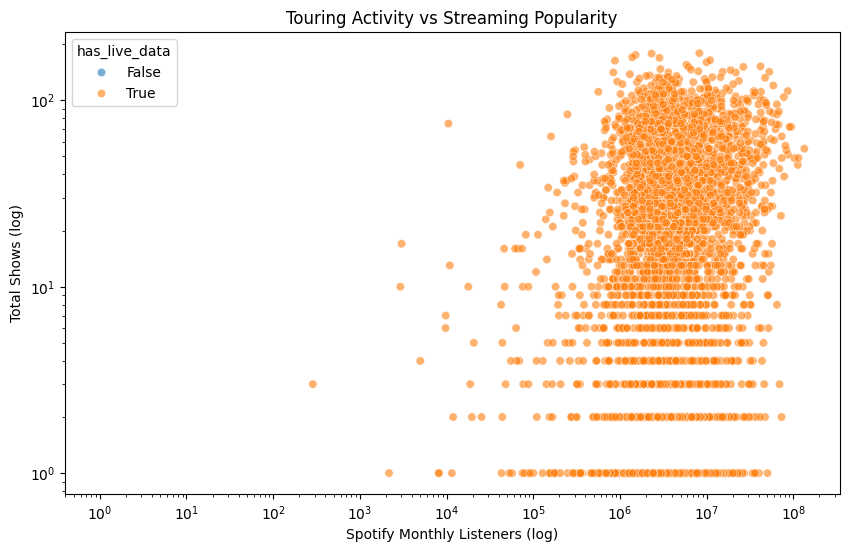

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df_select,
    x="sp_monthly_listeners",
    y="n_shows_total",
    hue="has_live_data",
    alpha=0.6
)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Spotify Monthly Listeners (log)")
plt.ylabel("Total Shows (log)")
plt.title("Touring Activity vs Streaming Popularity")

plt.show()

# FE en df_fe
experimentos aparte del df_select

In [75]:
df_select.shape

(7000, 71)

In [76]:
df_fe = df_select.copy()
df_fe.shape

(7000, 71)

In [77]:
df_fe["n_shows_total"].describe()

count    4913.000000
mean       24.299003
std        29.668945
min         0.000000
25%         1.000000
50%        13.000000
75%        38.000000
max       179.000000
Name: n_shows_total, dtype: float64

### live_conversion

In [78]:
import numpy as np

# =========================================================
# 1) live_conversion
# =========================================================

df_fe["live_conversion"] = np.where(
    df_fe["sp_monthly_listeners"] > 0,
    df_fe["n_shows_total"] / df_fe["sp_monthly_listeners"],
    np.nan
)

df_fe["log_live_conversion"] = np.log1p(df_fe["live_conversion"])


### touring_scale

In [79]:

# =========================================================
# 2) touring_scale
# =========================================================

df_fe["touring_scale"] = np.where(
    df_fe["n_shows_total"] > 0,
    df_fe["total_capacity_total"] / df_fe["n_shows_total"],
    np.nan
)

df_fe["log_touring_scale"] = np.log1p(df_fe["touring_scale"])


### dispersión geográfica

In [80]:

# =========================================================
# 3) dispersión geográfica
# =========================================================

df_fe["tour_spread_countries"] = np.where(
    df_fe["n_shows_total"] > 0,
    df_fe["n_countries_total"] / df_fe["n_shows_total"],
    np.nan
)

df_fe["tour_spread_cities"] = np.where(
    df_fe["n_shows_total"] > 0,
    df_fe["n_cities_total"] / df_fe["n_shows_total"],
    np.nan
)

### streaming_to_live_capacity

In [81]:


# =========================================================
# 4) streaming → live capacity
# =========================================================

df_fe["streaming_to_live_capacity"] = np.where(
    df_fe["sp_monthly_listeners"] > 0,
    df_fe["total_capacity_total"] / df_fe["sp_monthly_listeners"],
    np.nan
)

df_fe["log_streaming_to_live_capacity"] = np.log1p(df_fe["streaming_to_live_capacity"])



### targets continuos
log_n_shows_total
log_total_capacity_total

In [82]:
# =========================================================
# 5) targets continuos
# =========================================================

df_fe["log_n_shows_total"] = np.log1p(df_fe["n_shows_total"])
df_fe["log_total_capacity_total"] = np.log1p(df_fe["total_capacity_total"])



# REVISAR HACIA ABAJO

## live status

In [83]:
import numpy as np

# =========================================================
# 1) live_status
# =========================================================

conditions_status = [
    df_fe["muerto_disuelto"] == True,
    (df_fe["career_stage"] == "legendary") &
    (df_fe["n_shows_total"].isna()) &
    (df_fe["muerto_disuelto"] == False),
    df_fe["n_shows_total"] > 0,
    df_fe["n_shows_total"].isna()
]

choices_status = [
    "muerto_disuelto",
    "off_cycle",
    "active_live",
    "sin_datos_live"
]

df_fe["live_status"] = np.select(conditions_status, choices_status, default="otro")



In [84]:
df_fe.groupby("live_status").agg(
    artistas=("chartmetric_id", "count"),
    total_shows=("n_shows_total", "sum"),
    shows_promedio=("n_shows_total", "mean")
).sort_values("total_shows", ascending=False)

,artistas,total_shows,shows_promedio
live_status,,,
active_live,4053,119381.0,29.454972
muerto_disuelto,637,0.0,0.000000
off_cycle,30,0.0,NaN
otro,223,0.0,0.000000
sin_datos_live,2057,0.0,NaN


In [85]:
df_fe["live_status"].value_counts(dropna=False)

live_status
active_live        4053
sin_datos_live     2057
muerto_disuelto     637
otro                223
off_cycle            30
Name: count, dtype: int64

In [86]:
tabla = df_fe.groupby("live_status").agg(
    artistas=("chartmetric_id","count"),
    total_shows=("n_shows_total","sum")
)

tabla["prop_artistas"] = tabla["artistas"] / tabla["artistas"].sum()
tabla["prop_shows"] = tabla["total_shows"] / tabla["total_shows"].sum()

tabla.sort_values("total_shows", ascending=False)

,artistas,total_shows,prop_artistas,prop_shows
live_status,,,,
active_live,4053,119381.0,0.579000,1.0
muerto_disuelto,637,0.0,0.091000,0.0
off_cycle,30,0.0,0.004286,0.0
otro,223,0.0,0.031857,0.0
sin_datos_live,2057,0.0,0.293857,0.0


## life _intensity

In [87]:
import csv
from pathlib import Path
from collections import defaultdict

INPUT_SUMMARY = Path("chartmetric_liveevents_2024_2025_cohorte2/liveevents_2024_2025_summary_cohorte2.csv")

def to_int(value, default=0):
    try:
        return int(float(str(value).strip()))
    except:
        return default

if not INPUT_SUMMARY.exists():
    raise FileNotFoundError(f"No existe el archivo: {INPUT_SUMMARY}")

with open(INPUT_SUMMARY, "r", encoding="utf-8-sig", newline="") as f:
    rows = list(csv.DictReader(f))

if not rows:
    raise ValueError("El summary está vacío.")

rows_by_id = defaultdict(list)

for row in rows:
    cmid = to_int(row.get("chartmetric_id", ""))
    if cmid:
        rows_by_id[cmid].append(row)

duplicates = {cmid: group for cmid, group in rows_by_id.items() if len(group) > 1}

total_ids = len(rows_by_id)
total_duplicates = sum(len(group) - 1 for group in duplicates.values())

print("=== DETECCIÓN DE DUPLICADOS ===")
print("Archivo:", INPUT_SUMMARY)
print("Filas totales:", len(rows))
print("IDs únicos:", total_ids)
print("Duplicados totales:", total_duplicates)
print("Artistas con duplicados:", len(duplicates))

if not duplicates:
    print("\nNo se detectaron duplicados.")
else:
    print("\nPrimeros 20 artistas con duplicados:")
    for cmid, group in list(duplicates.items())[:20]:
        print(f"{cmid} | repeticiones: {len(group)} | artist_name: {group[-1].get('artist_name', '')}")

=== DETECCIÓN DE DUPLICADOS ===
Archivo: chartmetric_liveevents_2024_2025_cohorte2\liveevents_2024_2025_summary_cohorte2.csv
Filas totales: 5600
IDs únicos: 5600
Duplicados totales: 0
Artistas con duplicados: 0

No se detectaron duplicados.


In [88]:
print("live_status")
display(df_fe["live_status"].value_counts(dropna=False))

print("\nlive_intensity")
display(df_fe["live_intensity"].value_counts(dropna=False))

live_status


live_status
active_live        4053
sin_datos_live     2057
muerto_disuelto     637
otro                223
off_cycle            30
Name: count, dtype: int64


live_intensity


KeyError: 'live_intensity'

In [ ]:
df_fe["live_status"] = np.select(
    [
        df_fe["muerto_disuelto"] == True,
        (df_fe["career_stage"] == "legendary") &
        (df_fe["n_shows_total"].isna()) &
        (df_fe["muerto_disuelto"] == False),
        df_fe["n_shows_total"] > 0
    ],
    [
        "muerto_disuelto",
        "off_cycle",
        "active_live"
    ],
    default=np.nan
)

TypeError: Choicelist and default value do not have a common dtype: The DType <class 'numpy.dtypes._PyFloatDType'> could not be promoted by <class 'numpy.dtypes.StrDType'>. This means that no common DType exists for the given inputs. For example they cannot be stored in a single array unless the dtype is `object`. The full list of DTypes is: (<class 'numpy.dtypes.StrDType'>, <class 'numpy.dtypes.StrDType'>, <class 'numpy.dtypes.StrDType'>, <class 'numpy.dtypes._PyFloatDType'>)

In [ ]:
import csv
from collections import defaultdict

SUMMARY_FILE = "chartmetric_liveevents_2024_2025_cohorte2/liveevents_2024_2025_summary_cohorte2.csv"

def to_int(value, default=0):
    try:
        return int(float(str(value).strip()))
    except:
        return default

# Leer filas
with open(SUMMARY_FILE, "r", encoding="utf-8-sig", newline="") as f:
    rows = list(csv.DictReader(f))

# Agrupar por chartmetric_id
rows_by_id = defaultdict(list)

for row in rows:
    cmid = to_int(row.get("chartmetric_id", ""))
    if cmid:
        rows_by_id[cmid].append(row)

# Detectar duplicados
duplicates = {k: v for k, v in rows_by_id.items() if len(v) > 1}

print("=== DUPLICADOS DETECTADOS COHORTE2 ===")
print("Cantidad de artistas duplicados:", len(duplicates))
print()

# Mostrar detalle
for cmid, group in duplicates.items():
    print("======================================")
    print(f"chartmetric_id: {cmid}")
    print(f"repeticiones: {len(group)}")
    
    for i, row in enumerate(group, start=1):
        print(f"\n--- fila {i} ---")
        print("artist_name:", row.get("artist_name"))
        print("ok:", row.get("ok"))
        print("status_code:", row.get("status_code"))
        print("n_shows_2024:", row.get("n_shows_2024"))
        print("n_shows_2025:", row.get("n_shows_2025"))
        print("n_requests:", row.get("n_requests_live_2024_2025"))
        print("downloaded_at:", row.get("downloaded_at_utc"))
    
    print()

=== DUPLICADOS DETECTADOS COHORTE2 ===
Cantidad de artistas duplicados: 0



## limpio filas duplicadas live

In [ ]:
import csv
from pathlib import Path
from datetime import datetime

INPUT_SUMMARY = Path("chartmetric_liveevents_2024_2025_cohorte2/liveevents_2024_2025_summary_cohorte2.csv")
OUTPUT_SUMMARY = Path("chartmetric_liveevents_2024_2025_cohorte2/liveevents_2024_2025_summary_dedup_cohorte2.csv")

def to_int(value, default=0):
    try:
        return int(float(str(value).strip()))
    except:
        return default

def count_unique_ids(rows, id_col="chartmetric_id"):
    ids = []
    for row in rows:
        cmid = to_int(row.get(id_col, ""))
        if cmid:
            ids.append(cmid)
    return len(set(ids)), len(ids) - len(set(ids))

if not INPUT_SUMMARY.exists():
    raise FileNotFoundError(f"No existe el archivo de entrada: {INPUT_SUMMARY}")

with open(INPUT_SUMMARY, "r", encoding="utf-8-sig", newline="") as f:
    rows = list(csv.DictReader(f))

if not rows:
    raise ValueError("El summary está vacío.")

fieldnames = list(rows[0].keys())

latest_by_id = {}
for row in rows:
    cmid = to_int(row.get("chartmetric_id", ""))
    if cmid:
        latest_by_id[cmid] = row

dedup_rows = list(latest_by_id.values())

if not dedup_rows:
    raise ValueError("La deduplicación produjo 0 filas. Proceso cancelado.")

with open(OUTPUT_SUMMARY, "w", encoding="utf-8", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(dedup_rows)

with open(OUTPUT_SUMMARY, "r", encoding="utf-8-sig", newline="") as f:
    check_rows = list(csv.DictReader(f))

if not check_rows:
    raise ValueError("El archivo deduplicado se escribió vacío. Proceso cancelado.")

unique_ids_before, dup_before = count_unique_ids(rows)
unique_ids_after, dup_after = count_unique_ids(check_rows)

print("=== LIMPIEZA SUMMARY ===")
print("Filas originales:", len(rows))
print("IDs únicos originales:", unique_ids_before)
print("Duplicados originales:", dup_before)
print("Filas deduplicadas:", len(check_rows))
print("IDs únicos deduplicados:", unique_ids_after)
print("Duplicados deduplicados:", dup_after)
print("Archivo deduplicado creado:", OUTPUT_SUMMARY)

if dup_after != 0:
    raise ValueError("El archivo deduplicado todavía tiene duplicados. Proceso cancelado.")

=== LIMPIEZA SUMMARY ===
Filas originales: 2500
IDs únicos originales: 2500
Duplicados originales: 0
Filas deduplicadas: 2500
IDs únicos deduplicados: 2500
Duplicados deduplicados: 0
Archivo deduplicado creado: chartmetric_liveevents_2024_2025_cohorte2\liveevents_2024_2025_summary_dedup_cohorte2.csv


## reasigno filenames

In [ ]:
import shutil
from pathlib import Path
from datetime import datetime
import csv

BASE_DIR = Path("chartmetric_liveevents_2024_2025_cohorte2")

original = BASE_DIR / "liveevents_2024_2025_summary_cohorte2.csv"
dedup = BASE_DIR / "liveevents_2024_2025_summary_dedup_cohorte2.csv"

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
backup = BASE_DIR / f"liveevents_2024_2025_summary_backup_{timestamp}_cohorte2.csv"

def count_rows(path):
    with open(path, "r", encoding="utf-8-sig", newline="") as f:
        rows = list(csv.DictReader(f))
    return len(rows)

if not dedup.exists():
    raise FileNotFoundError(f"No existe el archivo deduplicado: {dedup}")

dedup_rows = count_rows(dedup)
if dedup_rows == 0:
    raise ValueError("El archivo deduplicado está vacío. Reemplazo cancelado.")

if original.exists():
    shutil.copy2(original, backup)
    print("Backup creado:", backup.name)
else:
    print("No existe archivo original. El deduplicado pasará a ser el oficial sin backup previo.")

shutil.copy2(dedup, original)
print("Archivo deduplicado copiado como oficial:", original.name)

final_rows = count_rows(original)
if final_rows != dedup_rows:
    raise ValueError(
        f"Verificación fallida: original final={final_rows}, dedup={dedup_rows}. "
        "El backup quedó disponible para recuperación."
    )

print("=== REEMPLAZO COMPLETADO ===")
print("Filas en dedup:", dedup_rows)
print("Filas en original final:", final_rows)
print("Proceso terminado.")

Archivo de backup previo eliminado para dejar espacio.
Original (con duplicados) renombrado a: liveevents_2024_2025_summary_condup_cohorte2.csv
No se encontró el archivo liveevents_2024_2025_summary_dedup_cohorte2.csv. Revisa si el nombre es correcto.

Proceso terminado.


## GRAFICOS

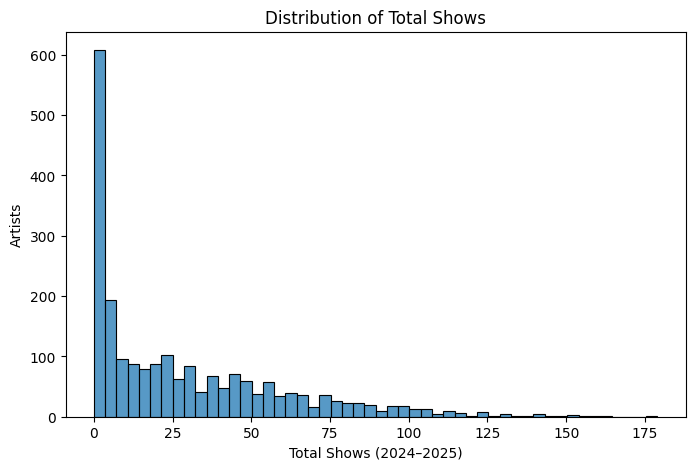

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.histplot(df_select["n_shows_total"], bins=50)

plt.xlabel("Total Shows (2024–2025)")
plt.ylabel("Artists")
plt.title("Distribution of Total Shows")

plt.show()

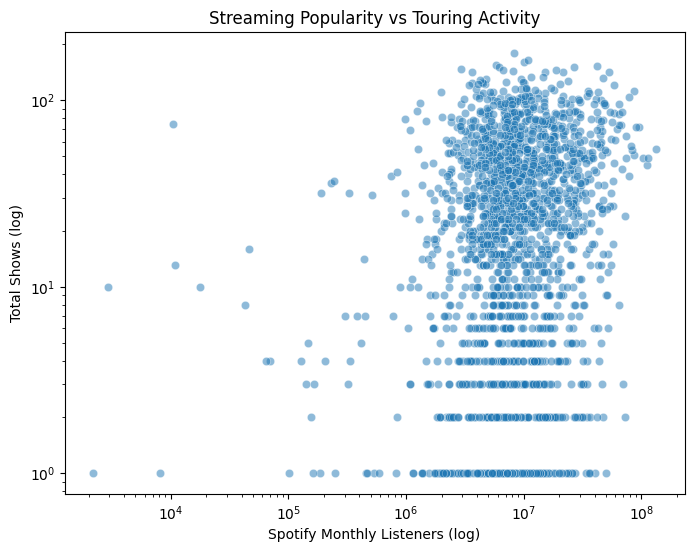

In [ ]:
df_plot = df_select[
    (df_select["sp_monthly_listeners"] > 0) &
    (df_select["n_shows_total"] > 0)
]

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_plot,
    x="sp_monthly_listeners",
    y="n_shows_total",
    alpha=0.5
)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Spotify Monthly Listeners (log)")
plt.ylabel("Total Shows (log)")
plt.title("Streaming Popularity vs Touring Activity")

plt.show()

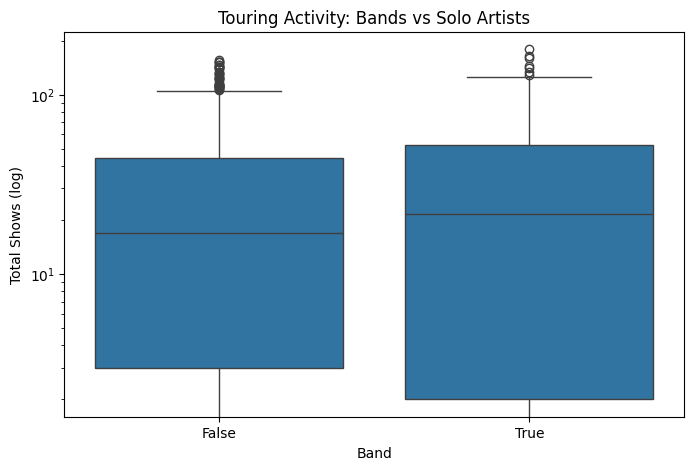

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_select,
    x="band",
    y="n_shows_total"
)

plt.yscale("log")

plt.xlabel("Band")
plt.ylabel("Total Shows (log)")
plt.title("Touring Activity: Bands vs Solo Artists")

plt.show()

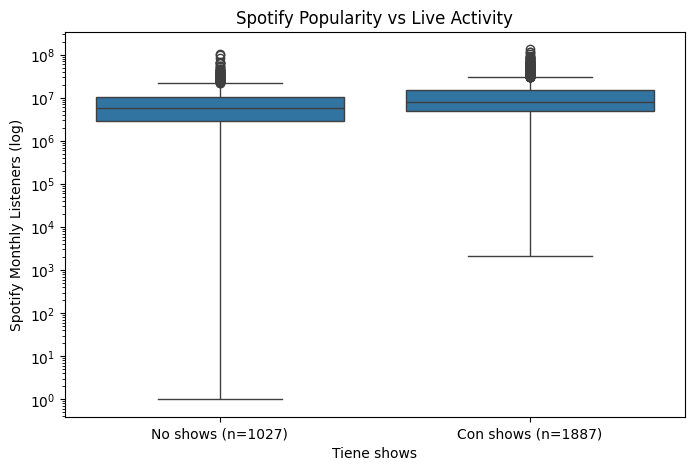

In [ ]:
df_plot = df_select.copy()

df_plot["tiene_shows"] = df_plot["n_shows_total"] > 0
df_plot["tiene_shows"] = df_plot["tiene_shows"].fillna(False)

# conteos
counts = df_plot["tiene_shows"].value_counts()

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_plot,
    x="tiene_shows",
    y="sp_monthly_listeners"
)

plt.yscale("log")

plt.xlabel("Tiene shows")
plt.ylabel("Spotify Monthly Listeners (log)")
plt.title("Spotify Popularity vs Live Activity")

# labels con n
plt.xticks(
    [0,1],
    [f"No shows (n={counts[False]})", f"Con shows (n={counts[True]})"]
)

plt.show()

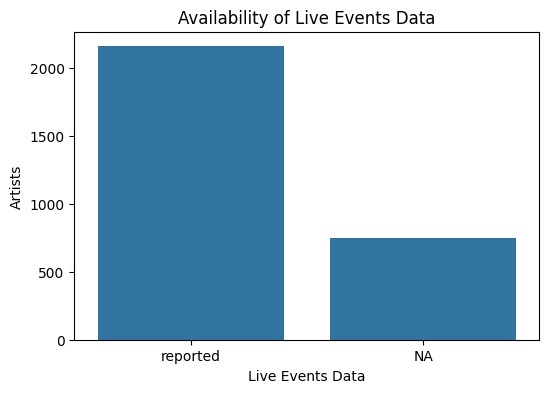

shows_status
reported    2161
NA           753
Name: count, dtype: int64


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_select["shows_status"] = df_select["n_shows_total"].apply(
    lambda x: "NA" if pd.isna(x) else "reported"
)

plt.figure(figsize=(6,4))

sns.countplot(
    data=df_select,
    x="shows_status"
)

plt.xlabel("Live Events Data")
plt.ylabel("Artists")
plt.title("Availability of Live Events Data")

plt.show()

print(df_select["shows_status"].value_counts(dropna=False))

career_stage
superstar     482
mainstream    231
legendary      39
mid-level       1
Name: count, dtype: int64


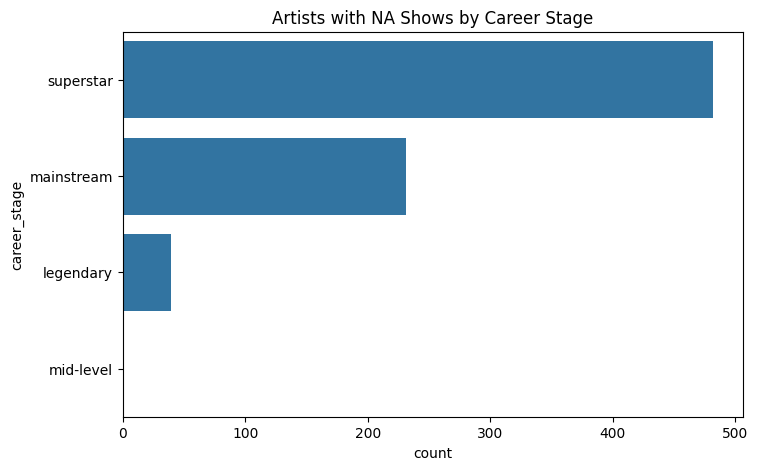

In [ ]:
df_nan = df_select[df_select["n_shows_total"].isna()]

career_nan = (
    df_nan["career_stage"]
    .value_counts()
)

print(career_nan)
plt.figure(figsize=(8,5))

sns.countplot(
    data=df_nan,
    y="career_stage",
    order=df_nan["career_stage"].value_counts().index
)

plt.title("Artists with NA Shows by Career Stage")

plt.show()

In [ ]:
df_nan_rank = df_select[df_select["n_shows_total"].isna()]

print(df_nan_rank["cm_artist_rank"].describe())

count       753.000000
mean       3752.560425
std        9351.749526
min           3.000000
25%        1345.000000
50%        2483.000000
75%        3607.000000
max      127239.000000
Name: cm_artist_rank, dtype: float64


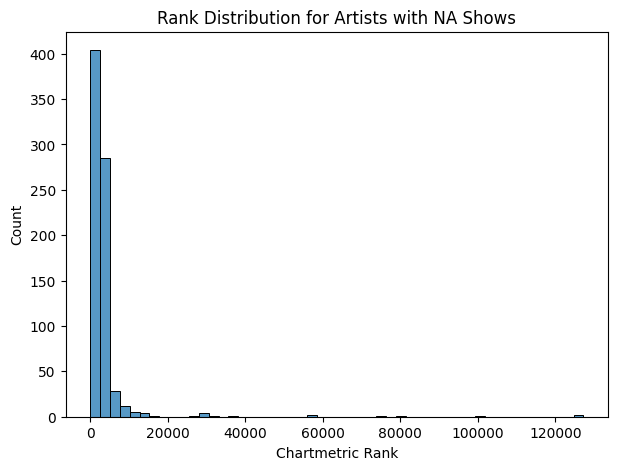

In [ ]:
plt.figure(figsize=(7,5))

sns.histplot(
    df_nan_rank["cm_artist_rank"],
    bins=50
)

plt.xlabel("Chartmetric Rank")
plt.title("Rank Distribution for Artists with NA Shows")

plt.show()

In [ ]:
df_nan = df_select[df_select["n_shows_total"].isna()]

print(
    df_nan["muerto_disuelto"].value_counts(dropna=False)
)

muerto_disuelto
False    753
Name: count, dtype: int64


In [ ]:
pd.crosstab(
    df_nan["career_stage"],
    df_nan["muerto_disuelto"],
    margins=True
)

muerto_disuelto,False,All
career_stage,,
legendary,39,39
mainstream,231,231
mid-level,1,1
superstar,482,482
All,753,753


In [ ]:
df_plot = df_fe[
    (df_fe["live_intensity"].notna()) &
    (df_fe["muerto_disuelto"] == False)
]

pd.crosstab(
    df_plot["career_stage"],
    df_plot["live_intensity"]
)

live_profile,actividad_media,alta_actividad,pocos_shows,sin_datos_live
career_stage,,,,
developing,0,0,1,0
legendary,100,18,80,39
mainstream,138,14,207,231
mid-level,0,0,1,1
superstar,615,47,666,482


In [ ]:
pd.crosstab(
    df_plot["career_stage"],
    df_plot["live_intensity"],
    normalize="index"
) * 100

live_profile,actividad_media,alta_actividad,pocos_shows,sin_datos_live
career_stage,,,,
developing,0.000000,0.000000,100.000000,0.000000
legendary,42.194093,7.594937,33.755274,16.455696
mainstream,23.389831,2.372881,35.084746,39.152542
mid-level,0.000000,0.000000,50.000000,50.000000
superstar,33.977901,2.596685,36.795580,26.629834


In [ ]:
df_plot = df_fe[
    (df_fe["live_intensity"].notna()) &
    (df_fe["muerto_disuelto"] == False)
]

tabla = pd.crosstab(
    df_plot["career_stage"],
    df_plot["live_intensity"]
)

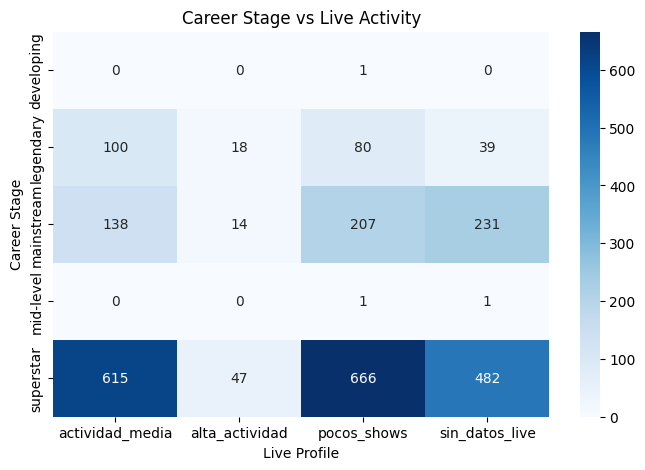

In [ ]:
plt.figure(figsize=(8,5))

sns.heatmap(
    tabla,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Live Profile")
plt.ylabel("Career Stage")
plt.title("Career Stage vs Live Activity")

plt.show()

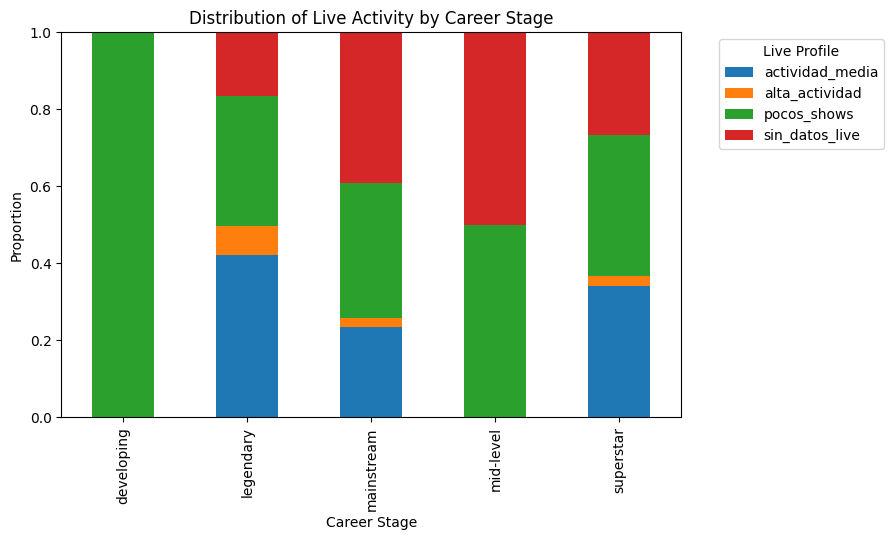

In [ ]:
tabla_prop = pd.crosstab(
    df_plot["career_stage"],
    df_plot["live_intensity"],
    normalize="index"
)

tabla_prop.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5)
)

plt.ylabel("Proportion")
plt.xlabel("Career Stage")
plt.title("Distribution of Live Activity by Career Stage")

plt.legend(title="Live Profile", bbox_to_anchor=(1.05,1))

plt.show()